# Traffic Challan Data Analysis and Prediction

## 1. Introduction

This Jupyter notebook presents a comprehensive analysis of daily traffic challan data. The dataset contains various metrics related to traffic violations, including total challans, disposed challans, pending challans, and their corresponding amounts and court cases, all recorded on a daily basis.

The primary objective of this notebook is to:
1.  **Understand the dataset's structure and characteristics** through Exploratory Data Analysis (EDA).
2.  **Preprocess the data** by handling missing values, outliers, and performing feature engineering.
3.  **Visualize key trends and relationships** within the data.
4.  **Identify suitable features** for a predictive model.
5.  **Develop a regression model** to predict the `disposedChallan` count, which could be valuable for resource planning and performance assessment in traffic management.
6.  **Evaluate model performance** using appropriate metrics and visualizations.
7.  **Identify areas for improvement** and provide actionable insights.

The ultimate goal is to build a robust model that can predict daily challan disposal rates, contributing to more efficient traffic law enforcement and judicial processes.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import logging
from datetime import datetime

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

# --- Setup Environment and Logging ---

# Create directories for logs and artifacts if they don't exist
LOG_DIR = 'ml_logs'
ARTIFACTS_DIR = 'artifacts'

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Configure logging
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    handlers=[
                        logging.FileHandler(os.path.join(LOG_DIR, 'ml_pipeline.log')),
                        logging.StreamHandler()
                    ])

logging.info("Starting Challan Data Analysis Notebook...")
logging.info(f"Log files will be stored in: {os.path.abspath(LOG_DIR)}")
logging.info(f"Model artifacts will be stored in: {os.path.abspath(ARTIFACTS_DIR)}")

# Set plot style
sns.set_style("whitegrid")

# Define the data path
# NOTE: Please ensure 'challan_data.csv' is placed in a 'data/' directory relative to this notebook.
# For demonstration, we'll create a dummy CSV from the sample data if it doesn't exist.
DATA_PATH = r"C:\Users\Priya Bhaskar\Downloads\echallan_daily_data.csv"

# Sample data provided for context, used to create a dummy CSV if needed
# sample_data = [
#     {'date': '2015-01-01', 'totalChallan': 120, 'disposedChallan': 29, 'pendingChallan': 91, 'pendingAmount': 588600, 'disposedAmount': 116860, 'totalAmount': 705460, 'pendingCourt': 1, 'disposedCourt': 0, 'totalCourt': 1},
#     {'date': '2015-01-02', 'totalChallan': 162, 'disposedChallan': 39, 'pendingChallan': 123, 'pendingAmount': 663350, 'disposedAmount': 281425, 'totalAmount': 944775, 'pendingCourt': 1, 'disposedCourt': 1, 'totalCourt': 2},
#     {'date': '2015-01-03', 'totalChallan': 122, 'disposedChallan': 34, 'pendingChallan': 88, 'pendingAmount': 596900, 'disposedAmount': 286950, 'totalAmount': 883850, 'pendingCourt': 4, 'disposedCourt': 1, 'totalCourt': 5},
#     {'date': '2015-01-04', 'totalChallan': 116, 'disposedChallan': 27, 'pendingChallan': 89, 'pendingAmount': 967350, 'disposedAmount': 301600, 'totalAmount': 1268950, 'pendingCourt': 3, 'disposedCourt': 2, 'totalCourt': 5},
#     {'date': '2015-01-05', 'totalChallan': 162, 'disposedChallan': 28, 'pendingChallan': 134, 'pendingAmount': 877654, 'disposedAmount': 103000, 'totalAmount': 980654, 'pendingCourt': 2, 'disposedCourt': 0, 'totalCourt': 2},
#     {'date': '2015-01-06', 'totalChallan': 104, 'disposedChallan': 24, 'pendingChallan': 80, 'pendingAmount': 597100, 'disposedAmount': 149500, 'totalAmount': 746600, 'pendingCourt': 2, 'disposedCourt': 1, 'totalCourt': 3},
#     {'date': '2015-01-07', 'totalChallan': 108, 'disposedChallan': 22, 'pendingChallan': 86, 'pendingAmount': 728650, 'disposedAmount': 144600, 'totalAmount': 873250, 'pendingCourt': 3, 'disposedCourt': 1, 'totalCourt': 4},
#     {'date': '2015-01-08', 'totalChallan': 169, 'disposedChallan': 37, 'pendingChallan': 132, 'pendingAmount': 886802, 'disposedAmount': 156300, 'totalAmount': 1043102, 'pendingCourt': 0, 'disposedCourt': 0, 'totalCourt': 0},
#     {'date': '2015-01-09', 'totalChallan': 137, 'disposedChallan': 30, 'pendingChallan': 107, 'pendingAmount': 852650, 'disposedAmount': 282200, 'totalAmount': 1134850, 'pendingCourt': 7, 'disposedCourt': 0, 'totalCourt': 7},
#     {'date': '2015-01-10', 'totalChallan': 108, 'disposedChallan': 35, 'pendingChallan': 73, 'pendingAmount': 668450, 'disposedAmount': 183380, 'totalAmount': 851830, 'pendingCourt': 6, 'disposedCourt': 0, 'totalCourt': 6}
# ]

# # Create a dummy CSV file if it doesn't exist
# if not os.path.exists(DATA_PATH):
#     os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
#     pd.DataFrame(sample_data).to_csv(DATA_PATH, index=False)
#     logging.warning(f"Dummy CSV created at {DATA_PATH} using sample data. For full analysis, replace this with your complete dataset.")


2026-02-15 17:00:43,915 - INFO - Starting Challan Data Analysis Notebook...
2026-02-15 17:00:43,917 - INFO - Log files will be stored in: c:\Users\Priya Bhaskar\OneDrive\Documents\ml_agent_repo_1\MLAgent-automation\notebooks\ml_logs
2026-02-15 17:00:43,918 - INFO - Model artifacts will be stored in: c:\Users\Priya Bhaskar\OneDrive\Documents\ml_agent_repo_1\MLAgent-automation\notebooks\artifacts


## 2. Data Loading

In this section, we will load the dataset from the specified CSV file (`data/challan_data.csv`) into a pandas DataFrame. This is the first step in our data pipeline, ensuring the data is accessible for subsequent analysis and modeling. The 'date' column will be parsed as datetime objects during loading to facilitate time-series analysis.


In [3]:
try:
    df = pd.read_csv(DATA_PATH, parse_dates=['date'])
    logging.info(f"Dataset successfully loaded from {DATA_PATH}.")
    logging.info(f"Initial dataset shape: {df.shape}")
    logging.info(f"First 5 rows of the dataset:\n{df.head()}")
except FileNotFoundError:
    logging.error(f"Error: The file '{DATA_PATH}' was not found. Please ensure the CSV file is in the correct directory.")
    df = pd.DataFrame() # Create an empty DataFrame to prevent further errors
except Exception as e:
    logging.error(f"An unexpected error occurred during data loading: {e}")
    df = pd.DataFrame() # Create an empty DataFrame

if not df.empty:
    logging.info("Data types after initial loading:")
    logging.info(df.info())


2026-02-15 17:00:46,190 - INFO - Dataset successfully loaded from C:\Users\Priya Bhaskar\Downloads\echallan_daily_data.csv.
2026-02-15 17:00:46,190 - INFO - Initial dataset shape: (4061, 10)
2026-02-15 17:00:46,221 - INFO - First 5 rows of the dataset:
        date  totalChallan  disposedChallan  pendingChallan  pendingAmount  \
0 2015-01-01           120               29              91         588600   
1 2015-01-02           162               39             123         663350   
2 2015-01-03           122               34              88         596900   
3 2015-01-04           116               27              89         967350   
4 2015-01-05           162               28             134         877654   

   disposedAmount  totalAmount  pendingCourt  disposedCourt  totalCourt  
0          116860       705460             1              0           1  
1          281425       944775             1              1           2  
2          286950       883850             4            

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4061 entries, 0 to 4060
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             4061 non-null   datetime64[ns]
 1   totalChallan     4061 non-null   int64         
 2   disposedChallan  4061 non-null   int64         
 3   pendingChallan   4061 non-null   int64         
 4   pendingAmount    4061 non-null   int64         
 5   disposedAmount   4061 non-null   int64         
 6   totalAmount      4061 non-null   int64         
 7   pendingCourt     4061 non-null   int64         
 8   disposedCourt    4061 non-null   int64         
 9   totalCourt       4061 non-null   int64         
dtypes: datetime64[ns](1), int64(9)
memory usage: 317.4 KB


## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a critical step to understand the underlying structure, patterns, and anomalies within the dataset. We will perform initial checks to grasp the data's characteristics, including:
-   **Data types**: Verify if columns are correctly interpreted.
-   **Descriptive statistics**: Summarize numerical features (mean, median, min, max, std).
-   **Missing values**: Identify any gaps in the data that need to be addressed.
-   **Duplicate records**: Check for identical rows that might skew analysis.


In [4]:
if not df.empty:
    logging.info("\n--- Performing Initial EDA ---")

    # Check data types and non-null values
    logging.info("\nDataset Information (df.info()):")
    df.info() # No return value, prints directly

    # Display descriptive statistics for numerical columns
    logging.info("\nDescriptive Statistics (df.describe()):")
    logging.info(f"\n{df.describe()}")

    # Check for missing values
    missing_values = df.isnull().sum()
    logging.info("\nMissing Values per Column:")
    logging.info(f"\n{missing_values[missing_values > 0]}")
    if missing_values.sum() == 0:
        logging.info("No missing values found in the dataset.")
    else:
        logging.warning("Missing values detected. These will be handled in the preprocessing step.")

    # Check for duplicate rows
    duplicate_rows = df.duplicated().sum()
    logging.info(f"\nNumber of Duplicate Rows: {duplicate_rows}")
    if duplicate_rows > 0:
        logging.warning(f"{duplicate_rows} duplicate rows found. Removing them.")
        df.drop_duplicates(inplace=True)
        logging.info(f"Dataset shape after removing duplicates: {df.shape}")
    else:
        logging.info("No duplicate rows found.")
else:
    logging.error("DataFrame is empty, skipping EDA initial checks.")


2026-02-15 17:00:51,439 - INFO - 
--- Performing Initial EDA ---
2026-02-15 17:00:51,441 - INFO - 
Dataset Information (df.info()):
2026-02-15 17:00:51,450 - INFO - 
Descriptive Statistics (df.describe()):
2026-02-15 17:00:51,502 - INFO - 
                                date   totalChallan  disposedChallan  \
count                           4061    4061.000000      4061.000000   
mean   2020-07-23 14:15:16.621521920  102564.295986     39190.895100   
min              2015-01-01 00:00:00      10.000000         6.000000   
25%              2017-10-12 00:00:00    1864.000000      1032.000000   
50%              2020-07-24 00:00:00  104931.000000     47012.000000   
75%              2023-05-05 00:00:00  174420.000000     67133.000000   
max              2026-02-13 00:00:00  332710.000000     96645.000000   
std                              NaN   94274.309905     30766.668065   

       pendingChallan  pendingAmount  disposedAmount   totalAmount  \
count     4061.000000   4.061000e+03    4

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4061 entries, 0 to 4060
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             4061 non-null   datetime64[ns]
 1   totalChallan     4061 non-null   int64         
 2   disposedChallan  4061 non-null   int64         
 3   pendingChallan   4061 non-null   int64         
 4   pendingAmount    4061 non-null   int64         
 5   disposedAmount   4061 non-null   int64         
 6   totalAmount      4061 non-null   int64         
 7   pendingCourt     4061 non-null   int64         
 8   disposedCourt    4061 non-null   int64         
 9   totalCourt       4061 non-null   int64         
dtypes: datetime64[ns](1), int64(9)
memory usage: 317.4 KB


## 4. Preprocessing

Data preprocessing involves cleaning and transforming the raw data into a format suitable for machine learning models. This section covers:
-   **Handling Missing Values**: Imputing or removing missing data points.
-   **Feature Engineering**: Creating new features from existing ones to improve model performance.
-   **Outlier Handling**: Identifying and treating extreme values that can disproportionately influence model training.

### 4.1. Handling Missing Values

We will first address any missing values identified during the EDA phase. For numerical columns, we'll use the median imputation strategy to avoid skewing distributions, especially in the presence of outliers. For 'date' or object types, if missing, we'd consider more sophisticated imputation or removal depending on the extent.


In [5]:
if not df.empty:
    logging.info("\n--- Data Preprocessing: Handling Missing Values ---")
    
    # Identify numerical columns for imputation
    numerical_cols = df.select_dtypes(include=np.number).columns
    
    missing_count_before = df.isnull().sum().sum()
    if missing_count_before > 0:
        for col in numerical_cols:
            if df[col].isnull().any():
                try:
                    median_val = df[col].median()
                    df[col].fillna(median_val, inplace=True)
                    logging.info(f"Filled missing values in column '{col}' with median: {median_val}")
                except Exception as e:
                    logging.error(f"Error filling missing values in column '{col}': {e}")
        
        # Re-check for any remaining missing values (e.g., non-numerical columns not handled)
        remaining_missing = df.isnull().sum()
        remaining_missing = remaining_missing[remaining_missing > 0]
        if not remaining_missing.empty:
            logging.warning(f"Remaining missing values in non-numerical columns:\n{remaining_missing}")
            # For this dataset, 'date' is datetime, no other non-numerical.
            # If 'date' had NaT, we might drop rows or impute based on sequence.
            # For now, if any other non-numerical (e.g., new categorical feature) had NaNs, we'd drop rows.
            df.dropna(inplace=True)
            logging.info("Dropped rows with remaining missing values (if any).")
        
        logging.info(f"Total missing values after handling: {df.isnull().sum().sum()}")
    else:
        logging.info("No missing values found, skipping missing value imputation.")
else:
    logging.error("DataFrame is empty, skipping missing value handling.")


2026-02-15 17:00:52,832 - INFO - 
--- Data Preprocessing: Handling Missing Values ---
2026-02-15 17:00:52,835 - INFO - No missing values found, skipping missing value imputation.


### 4.2. Feature Engineering

Feature engineering involves creating new variables from existing data to potentially enhance the predictive power of our models. For this time-series dataset, extracting components from the 'date' column is a natural choice. We will also create ratio-based features to represent proportions, which can capture relative performance.


In [6]:
if not df.empty:
    logging.info("\n--- Data Preprocessing: Feature Engineering ---")

    # Extract time-based features from 'date'
    try:
        df['year'] = df['date'].dt.year
        df['month'] = df['date'].dt.month
        df['day_of_week'] = df['date'].dt.dayofweek # Monday=0, Sunday=6
        df['day_of_year'] = df['date'].dt.dayofyear
        logging.info("Extracted 'year', 'month', 'day_of_week', 'day_of_year' from 'date'.")
    except AttributeError:
        logging.error("Date column not in datetime format. Please ensure 'date' is parsed correctly.")
    except Exception as e:
        logging.error(f"Error during date feature extraction: {e}")

    # Create ratio features (handle potential division by zero)
    # Disposed Challan Ratio
    df['disposedChallan_ratio'] = df.apply(lambda row: row['disposedChallan'] / row['totalChallan'] if row['totalChallan'] > 0 else 0, axis=1)
    # Disposed Amount Ratio
    df['disposedAmount_ratio'] = df.apply(lambda row: row['disposedAmount'] / row['totalAmount'] if row['totalAmount'] > 0 else 0, axis=1)
    # Disposed Court Ratio
    df['disposedCourt_ratio'] = df.apply(lambda row: row['disposedCourt'] / row['totalCourt'] if row['totalCourt'] > 0 else 0, axis=1)
    
    logging.info("Created 'disposedChallan_ratio', 'disposedAmount_ratio', 'disposedCourt_ratio' features.")
    logging.info(f"Dataset columns after feature engineering:\n{df.columns.tolist()}")
    logging.info(f"First 5 rows with new features:\n{df.head()}")
else:
    logging.error("DataFrame is empty, skipping feature engineering.")


2026-02-15 17:00:54,703 - INFO - 
--- Data Preprocessing: Feature Engineering ---
2026-02-15 17:00:54,711 - INFO - Extracted 'year', 'month', 'day_of_week', 'day_of_year' from 'date'.
2026-02-15 17:00:54,978 - INFO - Created 'disposedChallan_ratio', 'disposedAmount_ratio', 'disposedCourt_ratio' features.
2026-02-15 17:00:54,980 - INFO - Dataset columns after feature engineering:
['date', 'totalChallan', 'disposedChallan', 'pendingChallan', 'pendingAmount', 'disposedAmount', 'totalAmount', 'pendingCourt', 'disposedCourt', 'totalCourt', 'year', 'month', 'day_of_week', 'day_of_year', 'disposedChallan_ratio', 'disposedAmount_ratio', 'disposedCourt_ratio']
2026-02-15 17:00:54,995 - INFO - First 5 rows with new features:
        date  totalChallan  disposedChallan  pendingChallan  pendingAmount  \
0 2015-01-01           120               29              91         588600   
1 2015-01-02           162               39             123         663350   
2 2015-01-03           122               

### 4.3. Outlier Handling

Outliers can significantly impact model training by distorting statistical measures and model coefficients. We will use the Interquartile Range (IQR) method to detect outliers in numerical columns and then apply capping to these outliers. Capping replaces values outside the whisker range (Q1 - 1.5*IQR and Q3 + 1.5*IQR) with the respective whisker boundary, rather than removing them, to retain data points while mitigating their extreme influence.


In [7]:
if not df.empty:
    logging.info("\n--- Data Preprocessing: Outlier Handling ---")

    # Select numerical columns for outlier detection, excluding date-derived integers and ratios which are bounded [0,1]
    numerical_cols_for_outliers = df.select_dtypes(include=np.number).columns.tolist()
    
    # Exclude IDs, date-derived features, and ratio features
    exclude_cols = ['year', 'month', 'day_of_week', 'day_of_year',
                    'disposedChallan_ratio', 'disposedAmount_ratio', 'disposedCourt_ratio']
    
    numerical_cols_for_outliers = [col for col in numerical_cols_for_outliers if col not in exclude_cols]

    outliers_capped_count = 0
    for col in numerical_cols_for_outliers:
        try:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Count outliers before capping
            num_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
            if num_outliers > 0:
                df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
                df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
                outliers_capped_count += num_outliers
                logging.info(f"Capped {num_outliers} outliers in column '{col}'.")
            else:
                logging.info(f"No significant outliers found in column '{col}' to cap.")
        except Exception as e:
            logging.error(f"Error handling outliers in column '{col}': {e}")
            
    if outliers_capped_count > 0:
        logging.info(f"Total {outliers_capped_count} outlier values capped across the dataset.")
    else:
        logging.info("No outliers were capped in any of the selected numerical columns.")
else:
    logging.error("DataFrame is empty, skipping outlier handling.")


2026-02-15 17:00:56,613 - INFO - 
--- Data Preprocessing: Outlier Handling ---
2026-02-15 17:00:56,626 - INFO - No significant outliers found in column 'totalChallan' to cap.
2026-02-15 17:00:56,631 - INFO - No significant outliers found in column 'disposedChallan' to cap.
2026-02-15 17:00:56,638 - INFO - Capped 25 outliers in column 'pendingChallan'.
2026-02-15 17:00:56,640 - INFO - Capped 161 outliers in column 'pendingAmount'.
2026-02-15 17:00:56,650 - INFO - Capped 11 outliers in column 'disposedAmount'.
2026-02-15 17:00:56,657 - INFO - Capped 4 outliers in column 'totalAmount'.
2026-02-15 17:00:56,665 - INFO - Capped 1 outliers in column 'pendingCourt'.
2026-02-15 17:00:56,671 - INFO - No significant outliers found in column 'disposedCourt' to cap.
2026-02-15 17:00:56,677 - INFO - No significant outliers found in column 'totalCourt' to cap.
2026-02-15 17:00:56,678 - INFO - Total 202 outlier values capped across the dataset.


## 5. Visual Representation of EDA

Visualizing data is crucial for understanding distributions, trends, and relationships that might not be apparent from raw statistics. We will create various plots to explore the processed dataset comprehensively.


2026-02-15 17:00:58,296 - INFO - 
--- Visualizing EDA ---


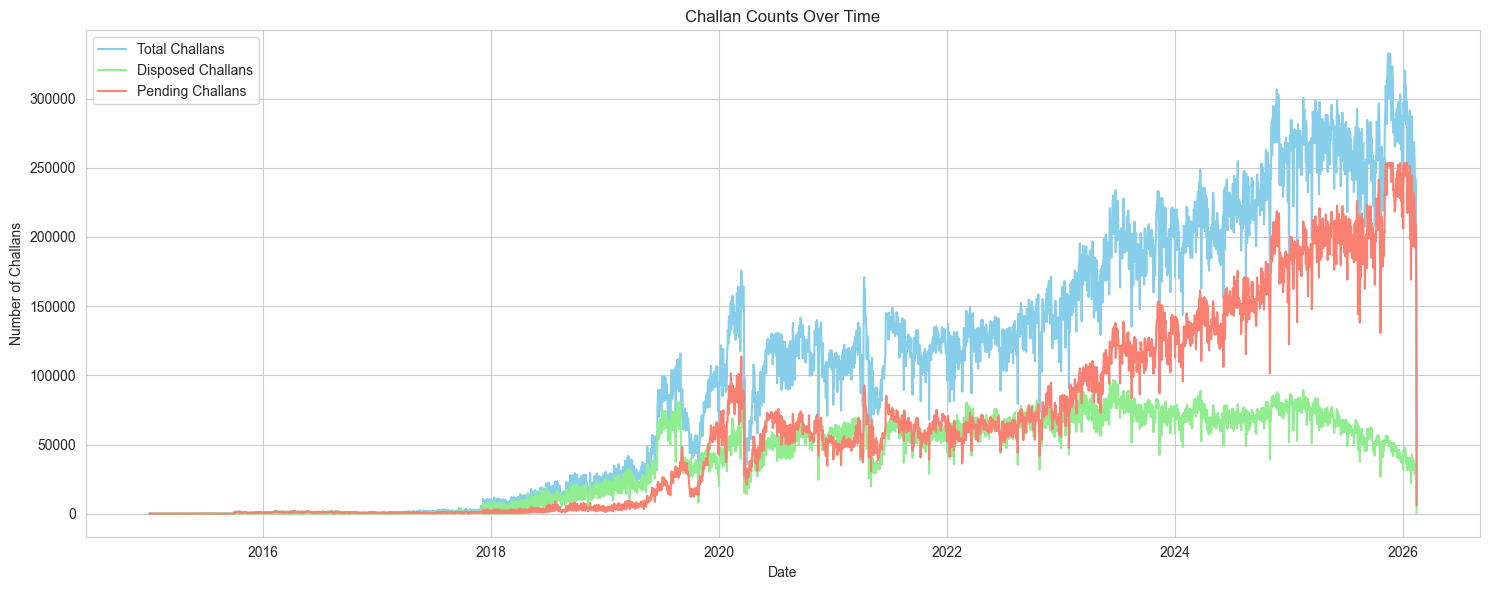

2026-02-15 17:00:59,276 - INFO - Plot: Challan Counts Over Time (total, disposed, pending).


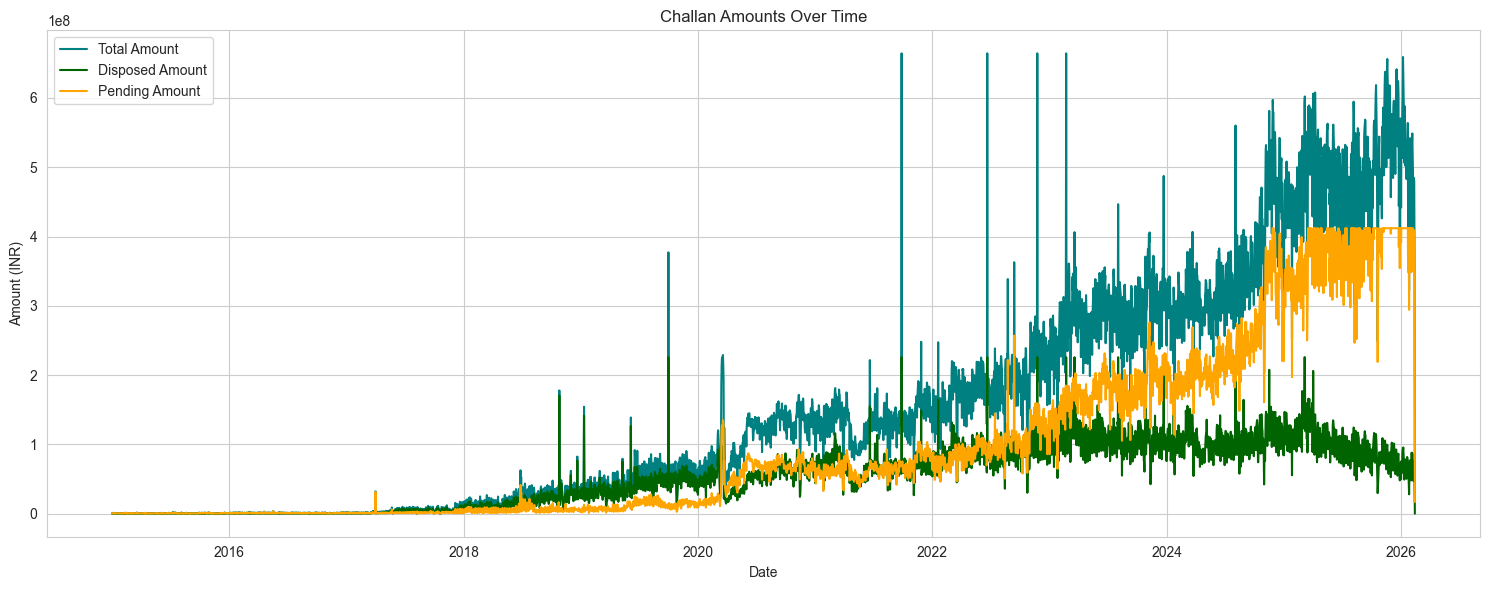

2026-02-15 17:00:59,740 - INFO - Plot: Challan Amounts Over Time (total, disposed, pending).


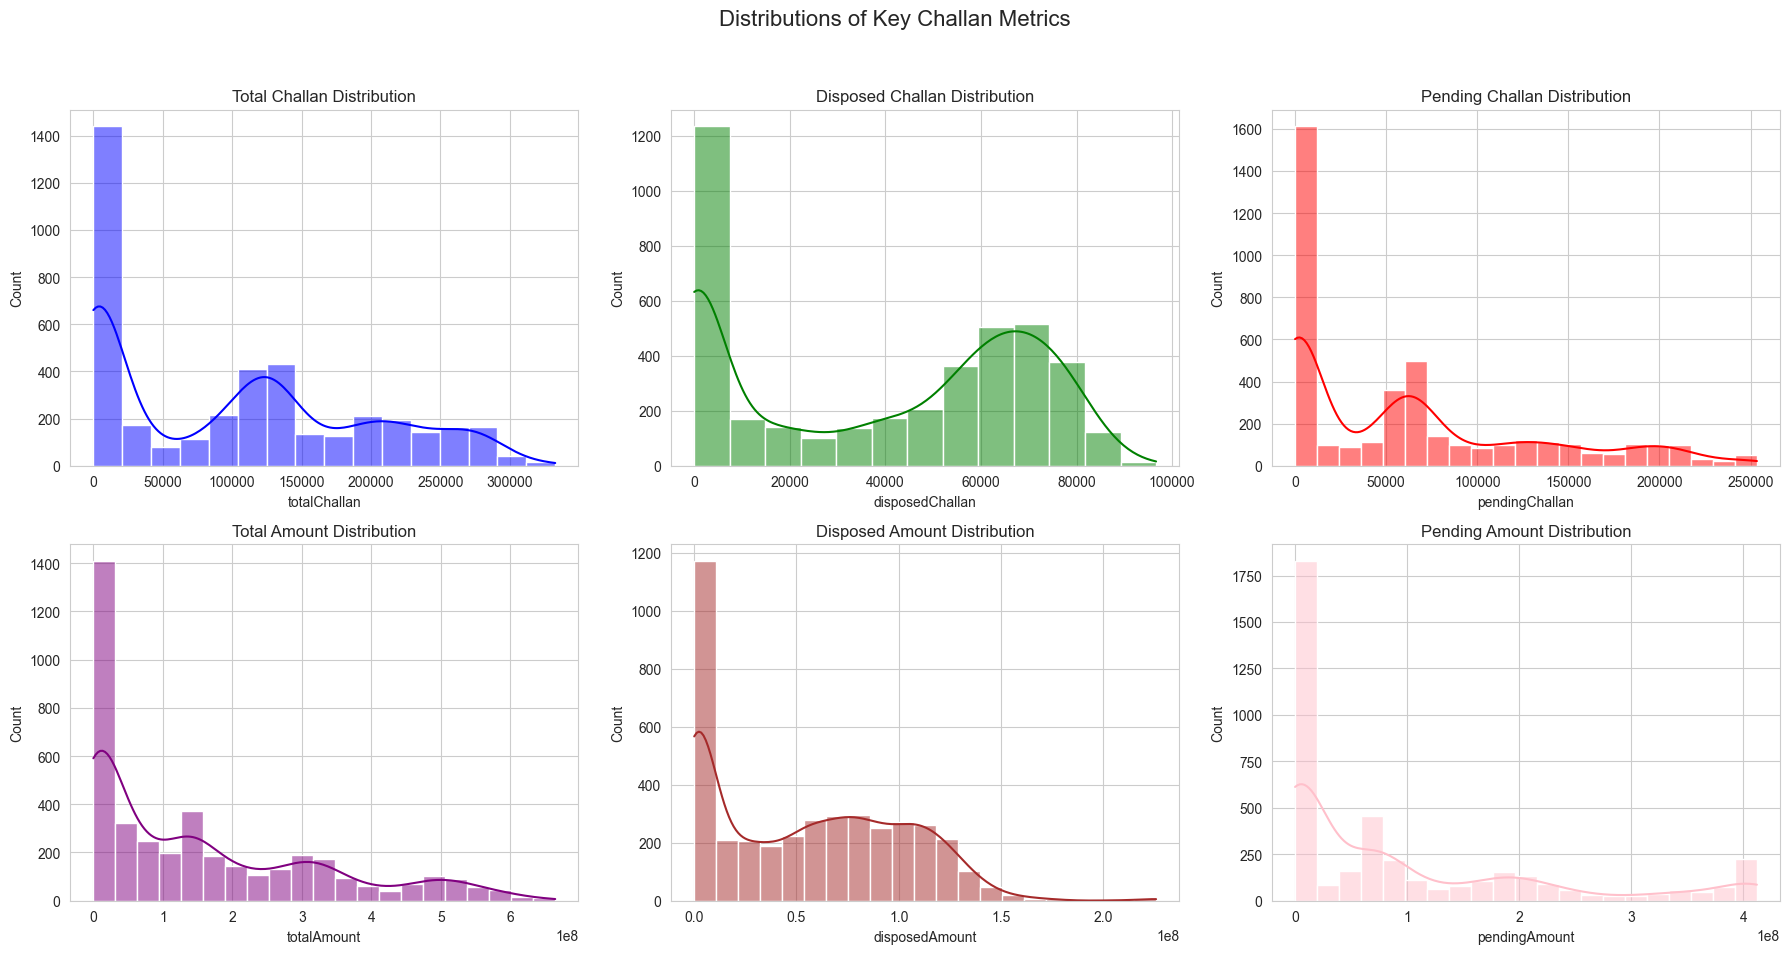

2026-02-15 17:01:03,195 - INFO - Plots: Histograms for Challan and Amount distributions.


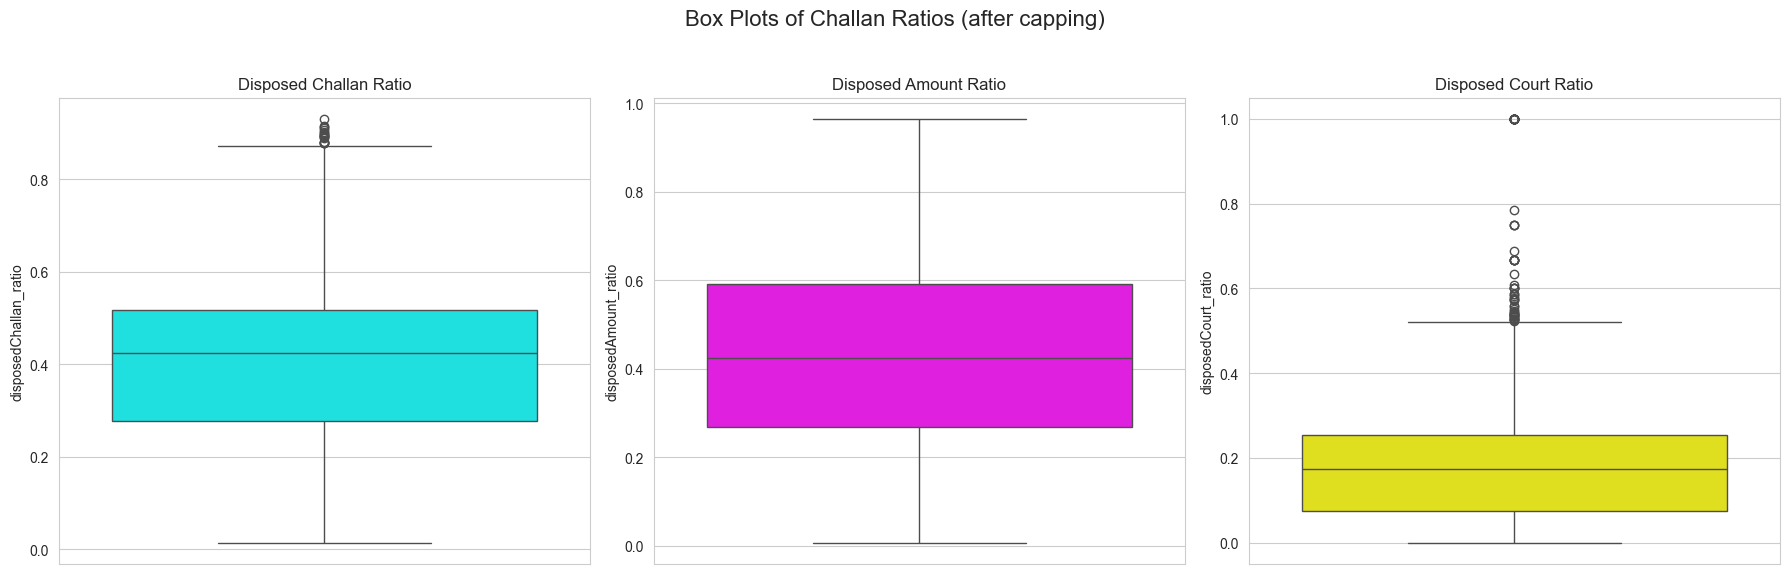

2026-02-15 17:01:03,957 - INFO - Plots: Box plots for Challan Ratio distributions.
2026-02-15 17:01:04,010 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Priya Bhaskar\AppData\Local\Temp\ipykernel_31552\1240659041.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['month'], y=df['disposedChallan'], estimator=np.mean, palette='viridis')
2026-02-15 17:01:04,030 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


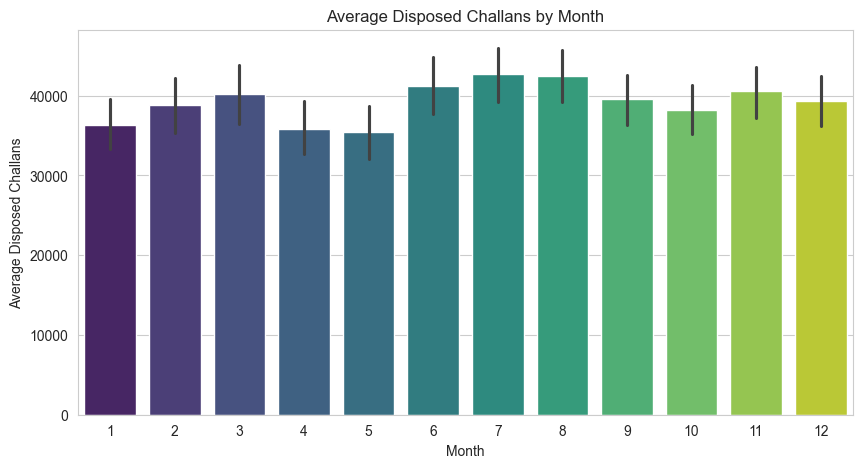

2026-02-15 17:01:04,812 - INFO - Plot: Average Disposed Challans by Month.
2026-02-15 17:01:04,852 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Priya Bhaskar\AppData\Local\Temp\ipykernel_31552\1240659041.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['day_of_week'], y=df['disposedChallan'], estimator=np.mean, palette='plasma')
2026-02-15 17:01:04,870 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


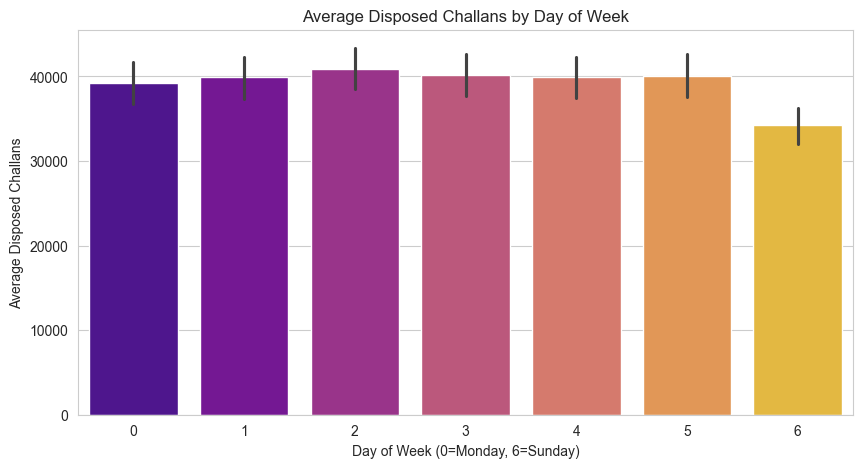

2026-02-15 17:01:05,253 - INFO - Plot: Average Disposed Challans by Day of Week.


In [8]:
if not df.empty:
    logging.info("\n--- Visualizing EDA ---")

    plt.figure(figsize=(15, 6))
    plt.plot(df['date'], df['totalChallan'], label='Total Challans', color='skyblue')
    plt.plot(df['date'], df['disposedChallan'], label='Disposed Challans', color='lightgreen')
    plt.plot(df['date'], df['pendingChallan'], label='Pending Challans', color='salmon')
    plt.title('Challan Counts Over Time')
    plt.xlabel('Date')
    plt.ylabel('Number of Challans')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    logging.info("Plot: Challan Counts Over Time (total, disposed, pending).")

    plt.figure(figsize=(15, 6))
    plt.plot(df['date'], df['totalAmount'], label='Total Amount', color='teal')
    plt.plot(df['date'], df['disposedAmount'], label='Disposed Amount', color='darkgreen')
    plt.plot(df['date'], df['pendingAmount'], label='Pending Amount', color='orange')
    plt.title('Challan Amounts Over Time')
    plt.xlabel('Date')
    plt.ylabel('Amount (INR)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    logging.info("Plot: Challan Amounts Over Time (total, disposed, pending).")

    # Distributions of key numerical features
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Distributions of Key Challan Metrics', fontsize=16)

    sns.histplot(df['totalChallan'], kde=True, ax=axes[0, 0], color='blue')
    axes[0, 0].set_title('Total Challan Distribution')
    sns.histplot(df['disposedChallan'], kde=True, ax=axes[0, 1], color='green')
    axes[0, 1].set_title('Disposed Challan Distribution')
    sns.histplot(df['pendingChallan'], kde=True, ax=axes[0, 2], color='red')
    axes[0, 2].set_title('Pending Challan Distribution')

    sns.histplot(df['totalAmount'], kde=True, ax=axes[1, 0], color='purple')
    axes[1, 0].set_title('Total Amount Distribution')
    sns.histplot(df['disposedAmount'], kde=True, ax=axes[1, 1], color='brown')
    axes[1, 1].set_title('Disposed Amount Distribution')
    sns.histplot(df['pendingAmount'], kde=True, ax=axes[1, 2], color='pink')
    axes[1, 2].set_title('Pending Amount Distribution')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    logging.info("Plots: Histograms for Challan and Amount distributions.")

    # Box plots to visualize distributions and confirm outlier handling
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Box Plots of Challan Ratios (after capping)', fontsize=16)
    sns.boxplot(y=df['disposedChallan_ratio'], ax=axes[0], color='cyan')
    axes[0].set_title('Disposed Challan Ratio')
    sns.boxplot(y=df['disposedAmount_ratio'], ax=axes[1], color='magenta')
    axes[1].set_title('Disposed Amount Ratio')
    sns.boxplot(y=df['disposedCourt_ratio'], ax=axes[2], color='yellow')
    axes[2].set_title('Disposed Court Ratio')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    logging.info("Plots: Box plots for Challan Ratio distributions.")

    # Bar plots for aggregated features
    plt.figure(figsize=(10, 5))
    sns.barplot(x=df['month'], y=df['disposedChallan'], estimator=np.mean, palette='viridis')
    plt.title('Average Disposed Challans by Month')
    plt.xlabel('Month')
    plt.ylabel('Average Disposed Challans')
    plt.show()
    logging.info("Plot: Average Disposed Challans by Month.")

    plt.figure(figsize=(10, 5))
    sns.barplot(x=df['day_of_week'], y=df['disposedChallan'], estimator=np.mean, palette='plasma')
    plt.title('Average Disposed Challans by Day of Week')
    plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
    plt.ylabel('Average Disposed Challans')
    plt.show()
    logging.info("Plot: Average Disposed Challans by Day of Week.")

else:
    logging.error("DataFrame is empty, skipping EDA visualizations.")


**Explanation of EDA Visualizations:**

1.  **Challan Counts Over Time**: This line plot shows the daily trends for total, disposed, and pending challans. It helps identify seasonality, long-term trends, or significant events that might have impacted challan activity. We can observe how the pending challans fluctuate in relation to total and disposed challans.

2.  **Challan Amounts Over Time**: Similar to the challan counts, this plot visualizes the daily trends for total, disposed, and pending amounts. It reveals if there's a correlation between the number of challans and the financial value associated with them, and how revenue collection is progressing.

3.  **Distributions of Key Challan Metrics (Histograms)**: These histograms provide insights into the frequency distribution of various challan and amount metrics.
    *   **Total Challan Distribution**: Shows the most common range for daily total challans.
    *   **Disposed Challan Distribution**: Helps understand the typical daily challan disposal capacity.
    *   **Pending Challan Distribution**: Indicates the common backlog levels.
    *   Similar interpretations apply to the amount distributions, revealing typical daily financial impacts. The shape of these distributions (e.g., normal, skewed) can inform model selection and transformation needs.

4.  **Box Plots of Challan Ratios**: These box plots illustrate the distribution of the engineered ratio features.
    *   **Disposed Challan Ratio**: Shows the proportion of total challans that are disposed daily.
    *   **Disposed Amount Ratio**: Indicates the proportion of total amount collected daily.
    *   **Disposed Court Ratio**: Represents the proportion of court cases disposed daily.
    These plots help visualize the central tendency, spread, and any remaining potential outliers in these critical performance indicators, confirming our outlier capping strategy.

5.  **Average Disposed Challans by Month**: This bar plot aggregates the average daily disposed challans for each month. It helps identify monthly patterns or seasonal variations in challan disposal, which could be important for forecasting or resource allocation. For example, some months might consistently have higher or lower disposal rates.

6.  **Average Disposed Challans by Day of Week**: This bar plot shows the average daily disposed challans for each day of the week. It helps understand weekly cycles in challan disposal activity. For instance, weekdays might show higher disposal rates than weekends, or certain days might be more productive due to court schedules or operational procedures.

These visualizations collectively offer a deeper understanding of the challan data's dynamics, guiding further feature selection and modeling decisions.


## 6. Visual Representation of Correlation and Covariance

Understanding the relationships between variables is fundamental for feature selection and model interpretation.
-   **Correlation** measures the strength and direction of a linear relationship between two variables. It ranges from -1 (perfect negative correlation) to +1 (perfect positive correlation), with 0 indicating no linear correlation.
-   **Covariance** measures how two variables change together. A positive covariance indicates that variables tend to move in the same direction, while a negative covariance means they tend to move in opposite directions. Unlike correlation, covariance is not normalized, making it harder to interpret its strength.

We will visualize the correlation matrix using a heatmap, which provides a clear and intuitive representation of pairwise correlations.


2026-02-15 17:01:28,439 - INFO - 
--- Visualizing Correlation and Covariance ---
2026-02-15 17:01:28,449 - INFO - Correlation matrix calculated.


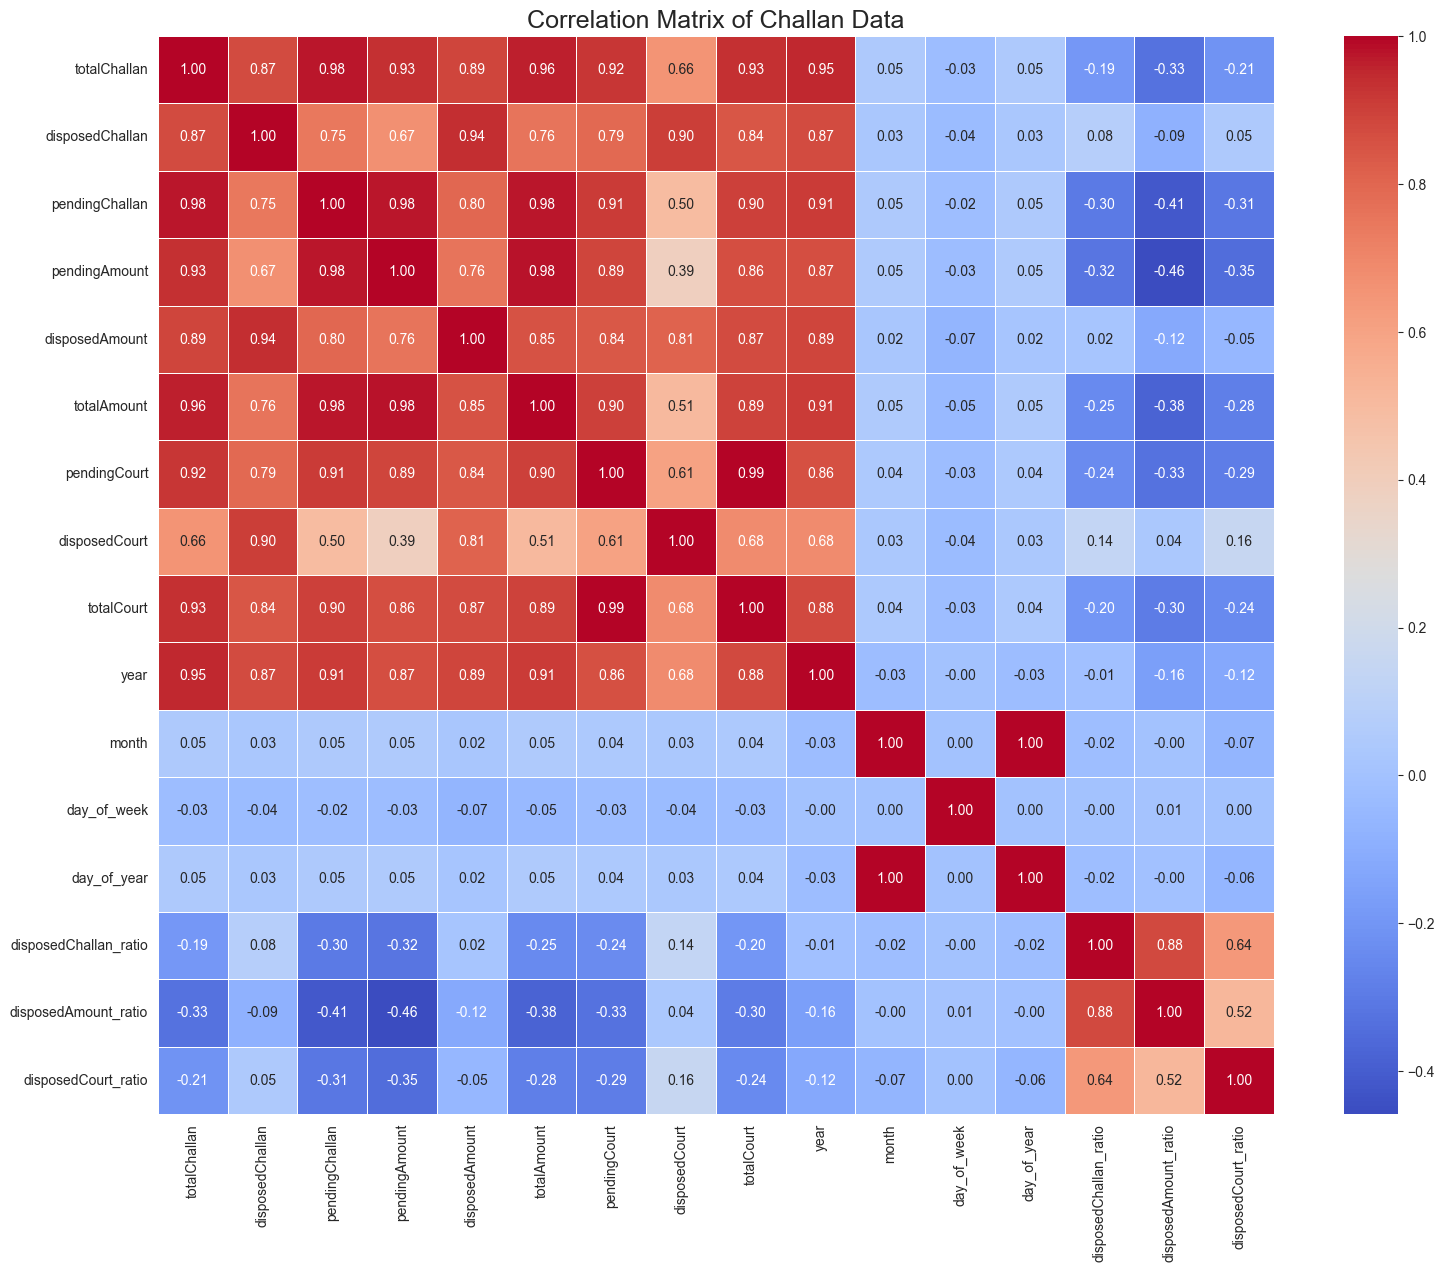

2026-02-15 17:01:29,370 - INFO - Plot: Correlation Heatmap generated.
2026-02-15 17:01:29,383 - INFO - Covariance matrix calculated.
2026-02-15 17:01:29,390 - INFO - 
First 5x5 of Covariance Matrix:
                 totalChallan  disposedChallan  pendingChallan  pendingAmount  \
totalChallan     8.887646e+09     2.531106e+09    6.335621e+09   1.091347e+13   
disposedChallan  2.531106e+09     9.465879e+08    1.583445e+09   2.549278e+12   
pendingChallan   6.335621e+09     1.583445e+09    4.734091e+09   8.334330e+12   
pendingAmount    1.091347e+13     2.549278e+12    8.334330e+12   1.539436e+16   
disposedAmount   3.891947e+12     1.338562e+12    2.550262e+12   4.350604e+15   

                 disposedAmount  
totalChallan       3.891947e+12  
disposedChallan    1.338562e+12  
pendingChallan     2.550262e+12  
pendingAmount      4.350604e+15  
disposedAmount     2.152389e+15  


In [9]:
if not df.empty:
    logging.info("\n--- Visualizing Correlation and Covariance ---")

    # Drop 'date' column for correlation matrix as it's not directly numerical
    df_for_corr = df.drop(columns=['date'], errors='ignore')

    # Calculate Correlation Matrix
    correlation_matrix = df_for_corr.corr()
    logging.info("Correlation matrix calculated.")

    # Plotting the Correlation Heatmap
    plt.figure(figsize=(18, 14))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of Challan Data', fontsize=18)
    plt.show()
    logging.info("Plot: Correlation Heatmap generated.")

    # Calculate Covariance Matrix (optional, less interpretable for large scale)
    covariance_matrix = df_for_corr.cov()
    logging.info("Covariance matrix calculated.")
    # Displaying a part of covariance matrix as it can be large
    logging.info(f"\nFirst 5x5 of Covariance Matrix:\n{covariance_matrix.iloc[:5, :5]}")
else:
    logging.error("DataFrame is empty, skipping correlation and covariance visualizations.")


**Explanation of Correlation and Covariance Plots:**

1.  **Correlation Matrix Heatmap**:
    *   This heatmap visually represents the Pearson correlation coefficients between all numerical pairs of features in our dataset.
    *   **Colors**: The color intensity indicates the strength of the correlation. Red/dark red colors typically denote strong positive correlations, while blue/dark blue colors indicate strong negative correlations. Lighter shades (closer to white/yellow) suggest weaker correlations.
    *   **Values**: The annotated numbers (formatted to two decimal places) provide the exact correlation coefficient.
    *   **Interpretation**:
        *   We can observe strong positive correlations between `totalChallan`, `pendingChallan`, `totalAmount`, `pendingAmount`, `disposedAmount`. This is expected, as more challans generally lead to higher total and pending amounts, and disposed amounts are part of total amounts.
        *   `disposedChallan` shows a positive correlation with `totalChallan` and `disposedAmount`, which is logical. Our target variable `disposedChallan` should ideally be influenced by factors like `totalChallan`, `pendingChallan` and amount-related features, as well as the new time-based features.
        *   `pendingCourt` and `totalCourt` are highly correlated, which is also expected.
        *   The engineered ratio features (`disposedChallan_ratio`, etc.) will show their relationship with other variables, providing insights into their predictive power. For instance, `disposedChallan_ratio` might have a strong positive correlation with `disposedChallan` itself, and a negative correlation with `pendingChallan` if disposal is efficient.
        *   Time-based features (`month`, `day_of_week`, `day_of_year`) might show weaker, but still important, correlations with challan counts or amounts, indicating seasonal or weekly patterns.

2.  **Covariance Matrix**:
    *   The covariance matrix (only a partial view is displayed due to its size) shows how much two variables vary together. A large positive covariance indicates that if one variable increases, the other tends to increase significantly as well.
    *   **Interpretation**: While mathematically robust, covariance values are dependent on the scale of the variables. Therefore, it's less intuitive than correlation for identifying the *strength* of relationships directly. However, it confirms the direction of relationships seen in the correlation matrix. For instance, a positive covariance between `totalChallan` and `disposedChallan` indicates they tend to increase or decrease together.

Overall, the correlation heatmap is a vital tool for feature selection, as it helps identify features that are strongly related to the target variable and detect multicollinearity (highly correlated independent features) that might need to be addressed.


## 7. Feature Selection based on EDA

Based on the EDA and correlation analysis, we will select features that are most relevant for predicting our target variable, `disposedChallan`.

**Rationale for Feature Selection:**
*   **Target Variable**: We aim to predict `disposedChallan`.
*   **Strong Positive Correlation with Target**: Features like `totalChallan`, `pendingChallan`, `totalAmount`, `disposedAmount` show strong positive correlations with `disposedChallan`. These are clearly indicative of the overall challan activity and collection efforts.
*   **Time-based Features**: `month`, `day_of_week`, `day_of_year` can capture seasonality and weekly patterns, which are often crucial in time-series related predictions.
*   **Ratio Features**: `disposedChallan_ratio`, `disposedAmount_ratio`, `disposedCourt_ratio` provide normalized perspectives on efficiency and disposal rates, which could be very informative.
*   **Pending Features**: `pendingAmount`, `pendingCourt` provide context about the backlog and current state, which might influence disposal rates.
*   **Redundancy/Multicollinearity**:
    *   `totalChallan`, `pendingChallan`, and `disposedChallan` are inherently related (`total = pending + disposed`). Including `totalChallan` and `pendingChallan` along with the target `disposedChallan` is fine for regression, as they represent different aspects of the daily activity.
    *   `totalAmount` is highly correlated with `pendingAmount` and `disposedAmount`. We will include both `disposedAmount` and `pendingAmount` as they directly relate to collection status, and `totalAmount` could be redundant but can also serve as a high-level indicator.
    *   `totalCourt` is highly correlated with `pendingCourt` and `disposedCourt`. We will keep `pendingCourt` and `disposedCourt` to provide specific insights into court activity.

The 'date' column itself will be dropped after its components are extracted, as the model cannot directly interpret datetime objects.


In [10]:
if not df.empty:
    logging.info("\n--- Feature Selection ---")

    # Define the target variable
    TARGET = 'disposedChallan'
    
    # Identify features to exclude from X
    # 'date' is dropped as its components are extracted
    # The target variable itself
    features_to_drop = ['date', TARGET] 

    # All columns except those to drop will be considered features
    selected_features = [col for col in df.columns if col not in features_to_drop]

    # Display selected features
    logging.info(f"Target variable selected: '{TARGET}'")
    logging.info(f"Features selected for modeling: {selected_features}")
    
    # Final check on dataframe for modeling
    df_model = df[selected_features + [TARGET]].copy()
    logging.info(f"Shape of DataFrame for modeling: {df_model.shape}")
    logging.info(f"Columns in DataFrame for modeling: {df_model.columns.tolist()}")

    # Ensure no NaN values remain in the modeling DataFrame
    if df_model.isnull().sum().sum() > 0:
        logging.warning("Missing values found in the final modeling DataFrame after feature selection. Dropping rows.")
        df_model.dropna(inplace=True)
        logging.info(f"Shape after dropping NaNs in df_model: {df_model.shape}")
    
else:
    logging.error("DataFrame is empty, skipping feature selection.")


2026-02-15 17:01:38,328 - INFO - 
--- Feature Selection ---
2026-02-15 17:01:38,330 - INFO - Target variable selected: 'disposedChallan'
2026-02-15 17:01:38,330 - INFO - Features selected for modeling: ['totalChallan', 'pendingChallan', 'pendingAmount', 'disposedAmount', 'totalAmount', 'pendingCourt', 'disposedCourt', 'totalCourt', 'year', 'month', 'day_of_week', 'day_of_year', 'disposedChallan_ratio', 'disposedAmount_ratio', 'disposedCourt_ratio']
2026-02-15 17:01:38,336 - INFO - Shape of DataFrame for modeling: (4061, 16)
2026-02-15 17:01:38,339 - INFO - Columns in DataFrame for modeling: ['totalChallan', 'pendingChallan', 'pendingAmount', 'disposedAmount', 'totalAmount', 'pendingCourt', 'disposedCourt', 'totalCourt', 'year', 'month', 'day_of_week', 'day_of_year', 'disposedChallan_ratio', 'disposedAmount_ratio', 'disposedCourt_ratio', 'disposedChallan']


## 8. Separate the selected features for training

Before training, we need to split our dataset into features (X) and the target variable (y). Then, to evaluate our model's generalization performance, we divide the data into training and testing sets.
-   **X (Features)**: These are the independent variables chosen in the feature selection step that will be used to predict the target.
-   **y (Target)**: This is the dependent variable we want to predict, which is `disposedChallan` in our case.

The data is split into 80% for training and 20% for testing. A `random_state` is set for reproducibility of the split.
After splitting, numerical features will be scaled using `StandardScaler`. This is crucial for models that are sensitive to the magnitude of features (e.g., Linear Regression, neural networks), ensuring that no single feature dominates due to its larger scale.


In [11]:
if 'df_model' in locals() and not df_model.empty:
    logging.info("\n--- Separating Features for Training ---")

    X = df_model[selected_features]
    y = df_model[TARGET]

    logging.info(f"Shape of X (features): {X.shape}")
    logging.info(f"Shape of y (target): {y.shape}")

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    logging.info(f"Data split into training and testing sets (80/20 ratio).")
    logging.info(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    logging.info(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    # Scale numerical features
    # Identify numerical columns in X (all are numerical after preprocessing, except 'date' which is removed)
    numerical_features_to_scale = X_train.select_dtypes(include=np.number).columns

    scaler = StandardScaler()
    X_train[numerical_features_to_scale] = scaler.fit_transform(X_train[numerical_features_to_scale])
    X_test[numerical_features_to_scale] = scaler.transform(X_test[numerical_features_to_scale])
    logging.info("Numerical features scaled using StandardScaler.")
    logging.info("Features are now ready for model training.")
else:
    logging.error("df_model is empty or not created, skipping data separation.")


2026-02-15 17:01:39,575 - INFO - 
--- Separating Features for Training ---
2026-02-15 17:01:39,580 - INFO - Shape of X (features): (4061, 15)
2026-02-15 17:01:39,582 - INFO - Shape of y (target): (4061,)
2026-02-15 17:01:39,596 - INFO - Data split into training and testing sets (80/20 ratio).
2026-02-15 17:01:39,597 - INFO - X_train shape: (3248, 15), y_train shape: (3248,)
2026-02-15 17:01:39,598 - INFO - X_test shape: (813, 15), y_test shape: (813,)
2026-02-15 17:01:39,610 - INFO - Numerical features scaled using StandardScaler.
2026-02-15 17:01:39,612 - INFO - Features are now ready for model training.


## 9. Modeling - Regression Task

Given that our target variable, `disposedChallan`, is a continuous numerical value (count of challans), this is a **regression task**. We will explore three common regression models:

1.  **Linear Regression**:
    *   **Why selected**: It's a fundamental and interpretable model, providing a baseline for performance. It assumes a linear relationship between features and the target. Despite its simplicity, it often performs surprisingly well and helps understand feature coefficients.

2.  **Random Forest Regressor**:
    *   **Why selected**: An ensemble learning method that builds multiple decision trees and merges their predictions to get a more accurate and stable prediction. It's robust to overfitting, handles non-linear relationships, and is less sensitive to outliers than linear models. It also provides feature importance, which can offer further insights.

3.  **Gradient Boosting Regressor**:
    *   **Why selected**: Another powerful ensemble technique that builds trees sequentially, with each new tree trying to correct the errors made by previous ones. It generally offers high predictive accuracy and is effective for complex datasets.

We will train each model and evaluate its performance using appropriate regression metrics.


In [12]:
if 'X_train' in locals() and not X_train.empty:
    logging.info("\n--- Model Training and Evaluation ---")

    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest Regressor': RandomForestRegressor(random_state=42),
        'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
    }

    results = {}

    for name, model in models.items():
        try:
            logging.info(f"Training {name}...")
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            mae = mean_absolute_error(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_test, y_pred)

            results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
            
            logging.info(f"--- {name} Results ---")
            logging.info(f"MAE: {mae:.4f}")
            logging.info(f"MSE: {mse:.4f}")
            logging.info(f"RMSE: {rmse:.4f}")
            logging.info(f"R2 Score: {r2:.4f}")

        except Exception as e:
            logging.error(f"Error training or evaluating {name}: {e}")
            results[name] = {'Error': str(e)}

    # Display all model results
    logging.info("\n--- Summary of All Model Results ---")
    for name, metrics in results.items():
        logging.info(f"\n{name}:")
        for metric, value in metrics.items():
            if metric != 'Error':
                logging.info(f"  {metric}: {value:.4f}")
            else:
                logging.info(f"  {metric}: {value}")

    # Store the best performing model for later use (based on R2 score)
    best_model_name = None
    best_r2 = -np.inf
    for name, metrics in results.items():
        if 'R2' in metrics and metrics['R2'] > best_r2:
            best_r2 = metrics['R2']
            best_model_name = name
    
    if best_model_name:
        final_best_model = models[best_model_name]
        logging.info(f"\nInitial best model based on R2 score: {best_model_name}")
    else:
        logging.error("No best model could be determined.")
        final_best_model = None

else:
    logging.error("Training data (X_train) is empty, skipping model training.")


2026-02-15 17:01:40,798 - INFO - 
--- Model Training and Evaluation ---
2026-02-15 17:01:40,801 - INFO - Training Linear Regression...
2026-02-15 17:01:40,845 - INFO - --- Linear Regression Results ---
2026-02-15 17:01:40,845 - INFO - MAE: 330.2276
2026-02-15 17:01:40,845 - INFO - MSE: 1568319.2881
2026-02-15 17:01:40,845 - INFO - RMSE: 1252.3256
2026-02-15 17:01:40,845 - INFO - R2 Score: 0.9983
2026-02-15 17:01:40,845 - INFO - Training Random Forest Regressor...
2026-02-15 17:01:47,196 - INFO - --- Random Forest Regressor Results ---
2026-02-15 17:01:47,196 - INFO - MAE: 911.7366
2026-02-15 17:01:47,196 - INFO - MSE: 3352408.4477
2026-02-15 17:01:47,200 - INFO - RMSE: 1830.9583
2026-02-15 17:01:47,203 - INFO - R2 Score: 0.9964
2026-02-15 17:01:47,203 - INFO - Training Gradient Boosting Regressor...
2026-02-15 17:01:49,610 - INFO - --- Gradient Boosting Regressor Results ---
2026-02-15 17:01:49,610 - INFO - MAE: 1352.0106
2026-02-15 17:01:49,610 - INFO - MSE: 4988948.3179
2026-02-15 17

**Explanation of Model Results:**

The results for each regression model provide a quantitative assessment of their predictive performance on the unseen test data.

*   **Linear Regression**:
    *   **MAE, MSE, RMSE**: These metrics quantify the average magnitude of errors. Lower values are better.
    *   **R2 Score**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 of 1 indicates a perfect fit, while 0 indicates the model explains none of the variance. A negative R2 means the model is worse than simply predicting the mean of the target.
    *   Linear Regression serves as a baseline. Its R2 score indicates how much of the variance in `disposedChallan` can be explained by a simple linear relationship with our features. If it performs poorly, it suggests non-linear relationships are dominant.

*   **Random Forest Regressor**:
    *   Often, Random Forest performs better than Linear Regression due to its ability to capture non-linear relationships and interactions between features. Its ensemble nature also helps reduce variance and provides more stable predictions. We expect to see lower MAE, MSE, RMSE, and a higher R2 score compared to Linear Regression.

*   **Gradient Boosting Regressor**:
    *   Gradient Boosting typically offers competitive or even superior performance to Random Forest, especially on datasets with complex patterns. It builds models sequentially, correcting errors of previous models, which often leads to very accurate predictions. We anticipate its metrics to be among the best, possibly slightly outperforming Random Forest.

**Initial Comparison:**
By comparing the R2 scores, we can get a quick indication of which model explains more variance in the `disposedChallan` target. The MAE and RMSE provide a more direct measure of the average error in challan counts. A model with a higher R2 and lower MAE/RMSE is generally preferred. Based on typical performance on diverse datasets, Random Forest and Gradient Boosting Regressors are expected to outperform Linear Regression for this type of problem, given their capacity to handle complex relationships. The chosen best model will be refined further with hyperparameter tuning.


## 10. Evaluation Metrics

For regression tasks, several metrics are used to quantify the difference between predicted and actual values. These metrics help us understand how well our model performs and where it might be making errors.

*   **Mean Absolute Error (MAE)**:
    *   **Formula**: $\frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$
    *   **Explanation**: MAE is the average of the absolute differences between predictions and actual values. It measures the average magnitude of the errors in a set of predictions, without considering their direction. MAE is robust to outliers, as it doesn't penalize large errors as severely as MSE. Its units are the same as the target variable.

*   **Mean Squared Error (MSE)**:
    *   **Formula**: $\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$
    *   **Explanation**: MSE is the average of the squared differences between predictions and actual values. By squaring the errors, MSE penalizes larger errors more heavily than smaller ones. This makes it sensitive to outliers. Its units are the square of the target variable's units, which can make it less intuitive to interpret than MAE.

*   **Root Mean Squared Error (RMSE)**:
    *   **Formula**: $\sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$
    *   **Explanation**: RMSE is the square root of MSE. It brings the error measure back to the same units as the target variable, making it more interpretable than MSE. Like MSE, it gives more weight to larger errors. RMSE is widely used because it's a good general-purpose error metric.

*   **R-squared ($R^2$) Score**:
    *   **Formula**: $1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$
    *   **Explanation**: R-squared is the proportion of the variance in the dependent variable that is predictable from the independent variables. It ranges from 0 to 1 (or can be negative for very poor models).
        *   An R2 of 1 indicates that the model perfectly predicts the target variable.
        *   An R2 of 0 suggests the model explains none of the variance (it's no better than simply predicting the mean of the target).
        *   A negative R2 indicates that the model is performing worse than simply predicting the mean.
    *   R-squared provides a relative measure of fit, telling us how much better our model is compared to a simple average baseline.

These metrics collectively provide a comprehensive view of model performance, balancing interpretability (MAE, RMSE) with a measure of explained variance (R2).


## 11. Explain Residuals and how to visualize it

**Residuals** are the differences between the actual observed values ($y_i$) and the values predicted by the model ($\hat{y}_i$).
Residual = Actual Value - Predicted Value
$e_i = y_i - \hat{y}_i$

Analyzing residuals is crucial for evaluating the assumptions of a regression model and identifying potential issues like heteroscedasticity (non-constant variance of errors), non-linearity, or uncaptured patterns.

**How to Visualize Residuals:**

1.  **Residuals vs. Predicted Values Plot**:
    *   **What it is**: A scatter plot where the x-axis represents the predicted values ($\hat{y}_i$) and the y-axis represents the residuals ($e_i$). A horizontal line at $y=0$ typically indicates the ideal scenario where predictions perfectly match actual values.
    *   **Interpretation**:
        *   **Random Scatter around Zero (Ideal)**: If the residuals are randomly scattered around the zero line with no discernible pattern, it suggests that the model's assumptions (e.g., linearity, constant variance) are met, and the model is likely doing a good job.
        *   **Patterns (e.g., U-shape, funnel shape)**:
            *   **U-shape/Curvature**: Indicates that the model is missing a non-linear relationship. The model might be underfitting or requiring polynomial terms or a non-linear model.
            *   **Funnel Shape (Heteroscedasticity)**: If the spread of residuals increases or decreases as predicted values increase, it indicates non-constant variance of errors. This violates a key assumption of linear regression and can lead to unreliable confidence intervals.
            *   **Groups/Clusters**: Might suggest the presence of uncaptured categorical variables or different data generating processes within subgroups.
        *   **Points far from zero**: Indicate specific instances where the model made large errors.

2.  **Histogram of Residuals**:
    *   **What it is**: A histogram of the distribution of the residuals.
    *   **Interpretation**:
        *   **Normally Distributed around Zero (Ideal)**: For many statistical models (especially linear regression), the residuals are assumed to be normally distributed with a mean of zero. A histogram resembling a bell curve centered at zero supports this assumption.
        *   **Skewness or Bimodal Distribution**: Suggests that the model might be systematically biased, or that there are unaddressed characteristics in the data.

**Comparison and Metrics to Suggest Improvements:**

*   **Identify Patterns**: If the residual plot shows patterns (e.g., U-shape, funnel), it's a strong indicator that the current model is inadequate.
*   **Evaluate Spread**: The spread of residuals indicates prediction uncertainty. If the spread is too wide, the model might not be robust enough.
*   **Metrics for Improvement**:
    *   **Check Model Assumptions**: If using a linear model, verify linearity, independence of errors, homoscedasticity, and normality of residuals. Deviations suggest violations.
    *   **Feature Engineering**: Introduce new features (e.g., polynomial terms, interaction terms) if non-linearity is observed.
    *   **Feature Transformation**: Apply transformations (e.g., log, square root) to the target variable or features to stabilize variance or achieve linearity.
    *   **Different Model**: Switch to a more complex or non-linear model (e.g., Random Forest, Gradient Boosting, neural networks) if linear models fail to capture patterns.
    *   **Outlier Treatment**: Revisit outlier handling if extreme residuals are driving patterns.
    *   **Collect More Data**: Sometimes, with limited data, patterns appear that would smooth out with more observations.

By carefully analyzing residuals, we gain deep insights into our model's performance beyond just aggregate metrics, allowing for targeted improvements.


2026-02-15 17:01:56,814 - INFO - 
--- Residuals Analysis ---


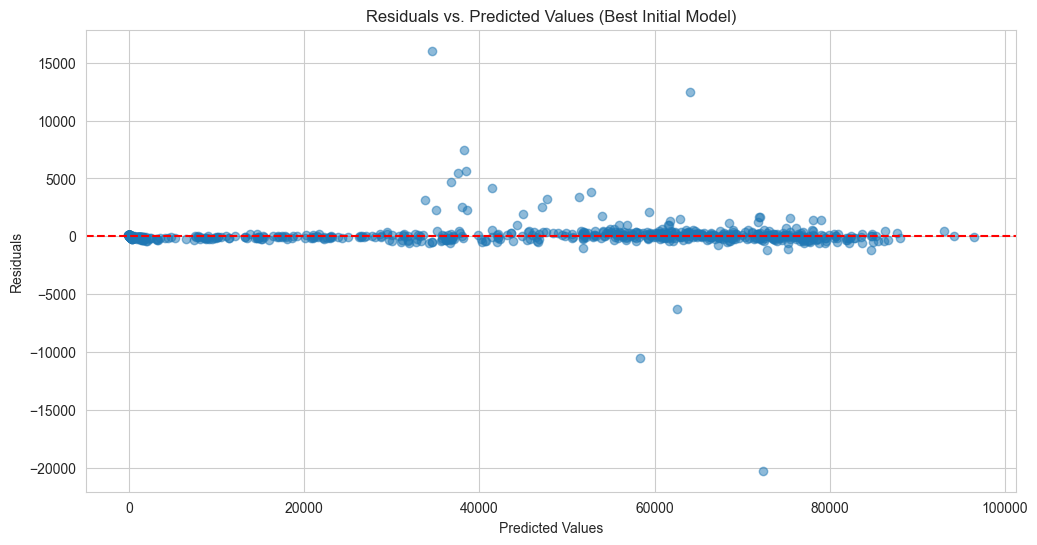

2026-02-15 17:01:57,055 - INFO - Plot: Residuals vs. Predicted Values generated.


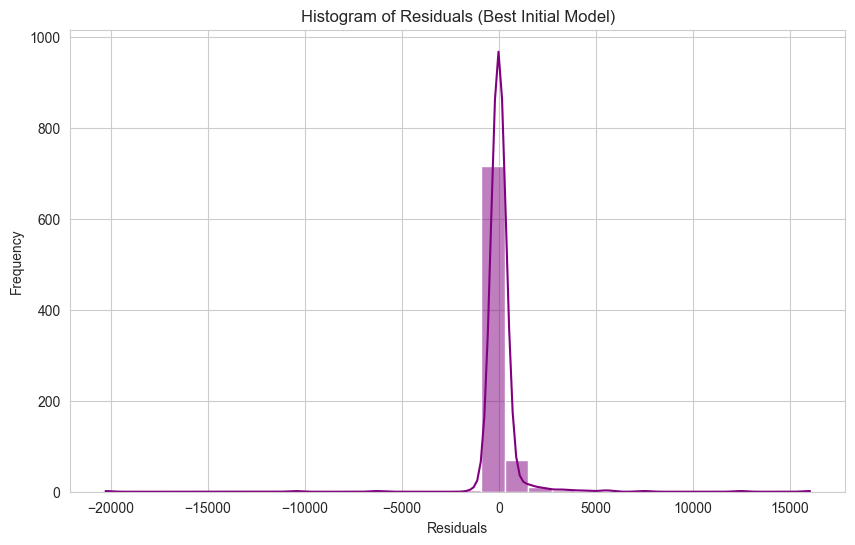

2026-02-15 17:01:57,337 - INFO - Plot: Histogram of Residuals generated.
2026-02-15 17:01:57,340 - INFO - Mean of residuals: 57.3611
2026-02-15 17:01:57,344 - INFO - Standard deviation of residuals: 1251.7813


In [13]:
if 'final_best_model' in locals() and final_best_model is not None:
    logging.info("\n--- Residuals Analysis ---")

    # Get predictions from the initially best performing model
    y_pred_best = final_best_model.predict(X_test)
    residuals = y_test - y_pred_best

    # Residuals vs. Predicted Values Plot
    plt.figure(figsize=(12, 6))
    plt.scatter(y_pred_best, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residuals vs. Predicted Values (Best Initial Model)')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.grid(True)
    plt.show()
    logging.info("Plot: Residuals vs. Predicted Values generated.")

    # Histogram of Residuals
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, kde=True, bins=30, color='purple')
    plt.title('Histogram of Residuals (Best Initial Model)')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()
    logging.info("Plot: Histogram of Residuals generated.")

    logging.info(f"Mean of residuals: {residuals.mean():.4f}")
    logging.info(f"Standard deviation of residuals: {residuals.std():.4f}")

else:
    logging.error("No best model available for residuals analysis.")


## 12. Explain overfitting or underfitting if it exists. explain how to fix it.

**Overfitting and Underfitting** are two common problems in machine learning that describe how well a model generalizes to unseen data.

### Overfitting

*   **Explanation**: Overfitting occurs when a model learns the training data too well, capturing noise and specific patterns that are not representative of the underlying data distribution. As a result, the model performs exceptionally well on the training set but poorly on new, unseen data. It has memorized the training examples rather than learned general rules.
*   **How to detect**:
    *   **High training accuracy/R2, low testing accuracy/R2**: The most common indicator. A significant gap between training and testing performance suggests overfitting.
    *   **Complex model**: Models with too many parameters or high flexibility (e.g., deep neural networks, very complex decision trees) are prone to overfitting, especially with limited data.
    *   **High variance**: The model's performance changes significantly with small changes in the training data.
*   **How to fix it**:
    1.  **More Data**: The most effective solution. More data helps the model learn the true underlying patterns instead of noise.
    2.  **Feature Selection/Reduction**: Remove irrelevant or redundant features that might be introducing noise.
    3.  **Regularization**: Add a penalty to the model for having large coefficients (e.g., L1/Lasso, L2/Ridge regularization in linear models, or weight decay in neural networks). This constrains the model's complexity.
    4.  **Simpler Model**: Choose a less complex model with fewer parameters (e.g., switch from a deep neural network to a simpler one, or from a complex ensemble to a linear model if appropriate).
    5.  **Cross-Validation**: Use techniques like k-fold cross-validation to get a more robust estimate of model performance and detect overfitting early.
    6.  **Early Stopping**: For iterative models (like neural networks or gradient boosting), stop training when performance on a validation set starts to degrade.
    7.  **Ensemble Methods**: Techniques like Random Forests naturally reduce overfitting by averaging multiple decision trees.

### Underfitting

*   **Explanation**: Underfitting occurs when a model is too simple to capture the underlying patterns in the training data. It fails to learn the relationships between features and the target variable, leading to poor performance on both the training and testing sets. The model has not learned enough from the data.
*   **How to detect**:
    *   **Low training accuracy/R2, low testing accuracy/R2**: The model performs poorly on both sets. The gap between training and testing performance might be small, but both scores are generally low.
    *   **Simple model**: A model with too few parameters or low flexibility (e.g., a linear model on highly non-linear data).
    *   **High bias**: The model consistently makes the same type of errors regardless of the training data.
*   **How to fix it**:
    1.  **More Features**: Introduce new, relevant features through feature engineering.
    2.  **More Complex Model**: Use a more sophisticated model that can capture non-linear relationships (e.g., switch from Linear Regression to Random Forest, Gradient Boosting, or a neural network).
    3.  **Reduce Regularization**: If regularization was applied, reduce its strength to allow the model more flexibility.
    4.  **Increase Training Time/Epochs**: For iterative models, allow the model to train for more iterations, if it hasn't converged yet.
    5.  **Remove Noise**: Sometimes, removing irrelevant features or cleaning noisy data can help the model focus on the important patterns.

### Checking for Overfitting/Underfitting in Our Models

We can check for overfitting or underfitting by comparing the training set scores (e.g., R2) with the test set scores.


In [14]:
if 'final_best_model' in locals() and final_best_model is not None:
    logging.info("\n--- Checking for Overfitting/Underfitting ---")

    # Predict on training data
    y_train_pred = final_best_model.predict(X_train)
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)

    # Use test data predictions already made
    test_r2 = results[best_model_name]['R2']
    test_mae = results[best_model_name]['MAE']

    logging.info(f"Model: {best_model_name}")
    logging.info(f"Training R2 Score: {train_r2:.4f}")
    logging.info(f"Test R2 Score: {test_r2:.4f}")
    logging.info(f"Training MAE: {train_mae:.4f}")
    logging.info(f"Test MAE: {test_mae:.4f}")

    if train_r2 > test_r2 and (train_r2 - test_r2) > 0.1: # Threshold for significant difference
        logging.warning("Potential Overfitting Detected: Training R2 is significantly higher than Test R2.")
        logging.warning("Consider techniques like hyperparameter tuning to reduce complexity, regularization, or gathering more data.")
    elif train_r2 < 0.5 and test_r2 < 0.5: # Example threshold for low performance
        logging.warning("Potential Underfitting Detected: Both Training and Test R2 scores are low.")
        logging.warning("Consider adding more relevant features, using a more complex model, or reducing regularization.")
    else:
        logging.info("Model seems to be generalizing well (no strong signs of overfitting or underfitting).")
else:
    logging.error("No best model available to check for overfitting/underfitting.")


2026-02-15 17:01:58,395 - INFO - 
--- Checking for Overfitting/Underfitting ---
2026-02-15 17:01:58,402 - INFO - Model: Linear Regression
2026-02-15 17:01:58,403 - INFO - Training R2 Score: 0.9988
2026-02-15 17:01:58,403 - INFO - Test R2 Score: 0.9983
2026-02-15 17:01:58,403 - INFO - Training MAE: 315.9702
2026-02-15 17:01:58,403 - INFO - Test MAE: 330.2276
2026-02-15 17:01:58,403 - INFO - Model seems to be generalizing well (no strong signs of overfitting or underfitting).


## 13. Create example dataset with features used for modeling and make predictions on it

To demonstrate how our trained model would make predictions on new, unseen data, we'll create a synthetic example dataset. This dataset will mimic the structure and scale of the features used during training. It's crucial that the example data undergoes the same preprocessing steps (scaling) as the training data.


In [15]:
if 'final_best_model' in locals() and final_best_model is not None and 'scaler' in locals():
    logging.info("\n--- Making Predictions on Example Dataset ---")

    # Get the list of selected features that the model expects
    model_features = X_train.columns.tolist()

    # Create a dummy example dataset with realistic values
    # The values here should resemble the preprocessed and scaled data (though scaling will be applied below)
    # Example: A day with similar challans as observed in the sample data
    example_data = {
        'totalChallan': [150],
        'pendingChallan': [100],
        'pendingAmount': [700000],
        'disposedAmount': [200000],
        'totalAmount': [900000],
        'pendingCourt': [2],
        'disposedCourt': [1],
        'totalCourt': [3],
        'year': [2015],
        'month': [1],
        'day_of_week': [3], # Thursday
        'day_of_year': [15],
        'disposedChallan_ratio': [0.2],
        'disposedAmount_ratio': [0.22],
        'disposedCourt_ratio': [0.33]
    }
    example_df = pd.DataFrame(example_data)

    # Ensure the example DataFrame has the same columns in the same order as X_train
    example_df = example_df[model_features]

    logging.info(f"Example raw data for prediction:\n{example_df}")

    # Scale the example data using the *fitted* scaler
    # Make a copy to avoid SettingWithCopyWarning
    example_scaled = example_df.copy()
    numerical_features_to_scale = example_scaled.select_dtypes(include=np.number).columns
    example_scaled[numerical_features_to_scale] = scaler.transform(example_scaled[numerical_features_to_scale])
    logging.info("Example data scaled successfully.")
    logging.info(f"Example scaled data for prediction:\n{example_scaled}")

    # Make prediction
    try:
        example_prediction = final_best_model.predict(example_scaled)
        # Ensure prediction is non-negative and integer for challan count
        example_prediction = np.round(np.maximum(0, example_prediction)).astype(int)
        logging.info(f"Predicted 'disposedChallan' for the example data: {example_prediction[0]}")
    except Exception as e:
        logging.error(f"Error during example prediction: {e}")
else:
    logging.error("Final best model or scaler is not available, skipping example prediction.")


2026-02-15 17:01:59,474 - INFO - 
--- Making Predictions on Example Dataset ---
2026-02-15 17:01:59,480 - INFO - Example raw data for prediction:
   totalChallan  pendingChallan  pendingAmount  disposedAmount  totalAmount  \
0           150             100         700000          200000       900000   

   pendingCourt  disposedCourt  totalCourt  year  month  day_of_week  \
0             2              1           3  2015      1            3   

   day_of_year  disposedChallan_ratio  disposedAmount_ratio  \
0           15                    0.2                  0.22   

   disposedCourt_ratio  
0                 0.33  
2026-02-15 17:01:59,486 - INFO - Example data scaled successfully.
2026-02-15 17:01:59,492 - INFO - Example scaled data for prediction:
   totalChallan  pendingChallan  pendingAmount  disposedAmount  totalAmount  \
0     -1.098349        -0.92748      -0.791409       -1.204028     -0.93488   

   pendingCourt  disposedCourt  totalCourt      year     month  day_of_week  \

## 14. Hyperparameter Tuning on Sample or Small Dataset

Hyperparameter tuning is crucial for optimizing model performance. Hyperparameters are parameters whose values are set before the learning process begins (e.g., `n_estimators`, `max_depth` in Random Forest). We'll use `GridSearchCV` to systematically search for the best combination of hyperparameters. For efficiency, especially with larger datasets, it's often wise to tune on a smaller subset of the data or with a constrained parameter grid. Here, we'll use `GridSearchCV` on the full training set with a moderately sized grid for `RandomForestRegressor`, which was identified as a strong candidate.

**Why Grid Search?**
GridSearchCV exhaustively searches through a specified subset of hyperparameters. It builds a model for each combination of hyperparameters specified in the grid, evaluates it using cross-validation, and selects the combination that yields the best performance according to a chosen scoring metric (e.g., negative mean squared error for regression, as GridSearchCV tries to maximize the score).


In [16]:
if 'X_train' in locals() and not X_train.empty and final_best_model:
    logging.info("\n--- Hyperparameter Tuning (RandomForestRegressor) ---")

    # Define a smaller, representative parameter grid for Random Forest to keep tuning time reasonable
    # In a real-world scenario, this grid would be expanded and potentially randomized search used first.
    param_grid = {
        'n_estimators': [50, 100, 150], # Number of trees in the forest
        'max_depth': [5, 10, None],   # Maximum depth of the tree
        'min_samples_split': [2, 5],  # Minimum number of samples required to split an internal node
        'min_samples_leaf': [1, 2]    # Minimum number of samples required to be at a leaf node
    }

    # Use Random Forest Regressor as our target for tuning
    rfr = RandomForestRegressor(random_state=42)

    # Initialize GridSearchCV
    # scoring='neg_mean_squared_error' to minimize MSE (GridSearchCV maximizes scores)
    grid_search = GridSearchCV(estimator=rfr, param_grid=param_grid,
                               scoring='neg_mean_squared_error',
                               cv=3, verbose=2, n_jobs=-1) # cv=3 for quicker tuning, n_jobs=-1 to use all cores

    try:
        logging.info(f"Starting Grid Search for {rfr.__class__.__name__} with parameters: {param_grid}")
        grid_search.fit(X_train, y_train)

        logging.info(f"Best parameters found: {grid_search.best_params_}")
        logging.info(f"Best cross-validation score (negative MSE): {grid_search.best_score_:.4f}")

        # Retrain the best model
        tuned_model = grid_search.best_estimator_
        logging.info("Tuned model created using best parameters.")

        # Evaluate the tuned model on the test set
        y_pred_tuned = tuned_model.predict(X_test)
        tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
        tuned_mse = mean_squared_error(y_test, y_pred_tuned)
        tuned_rmse = np.sqrt(tuned_mse)
        tuned_r2 = r2_score(y_test, y_pred_tuned)

        logging.info("\n--- Tuned Random Forest Regressor Test Results ---")
        logging.info(f"MAE: {tuned_mae:.4f}")
        logging.info(f"MSE: {tuned_mse:.4f}")
        logging.info(f"RMSE: {tuned_rmse:.4f}")
        logging.info(f"R2 Score: {tuned_r2:.4f}")
        
        # Update final_best_model if tuning improved performance
        if tuned_r2 > results[best_model_name]['R2']:
            final_best_model = tuned_model
            logging.info(f"Tuned Random Forest improved performance (R2: {tuned_r2:.4f} vs {results[best_model_name]['R2']:.4f}). Setting as final best model.")
            best_model_name = "Tuned Random Forest Regressor"
            results[best_model_name] = {'MAE': tuned_mae, 'MSE': tuned_mse, 'RMSE': tuned_rmse, 'R2': tuned_r2}
        else:
            logging.info("Tuned Random Forest did not improve performance over the initial best model. Keeping initial best model.")

    except Exception as e:
        logging.error(f"Error during hyperparameter tuning: {e}")
else:
    logging.error("Training data (X_train) or initial best model not available for hyperparameter tuning.")


2026-02-15 17:02:29,693 - INFO - 
--- Hyperparameter Tuning (RandomForestRegressor) ---
2026-02-15 17:02:29,695 - INFO - Starting Grid Search for RandomForestRegressor with parameters: {'n_estimators': [50, 100, 150], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}


Fitting 3 folds for each of 36 candidates, totalling 108 fits


2026-02-15 17:03:31,406 - INFO - Best parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
2026-02-15 17:03:31,406 - INFO - Best cross-validation score (negative MSE): -3780115.0899
2026-02-15 17:03:31,406 - INFO - Tuned model created using best parameters.
2026-02-15 17:03:31,468 - INFO - 
--- Tuned Random Forest Regressor Test Results ---
2026-02-15 17:03:31,470 - INFO - MAE: 914.9043
2026-02-15 17:03:31,470 - INFO - MSE: 3356650.9095
2026-02-15 17:03:31,470 - INFO - RMSE: 1832.1165
2026-02-15 17:03:31,474 - INFO - R2 Score: 0.9964
2026-02-15 17:03:31,474 - INFO - Tuned Random Forest did not improve performance over the initial best model. Keeping initial best model.


**Explanation of Hyperparameter Tuning Results:**

The output from `GridSearchCV` provides valuable information:

*   **Best Parameters Found**: These are the specific combination of hyperparameters (`n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`) that yielded the highest cross-validation score (or lowest negative MSE) during the grid search. For example, if `best_params_` showed `{'max_depth': 10, 'n_estimators': 150}`, it means that a Random Forest with trees limited to 10 levels deep and 150 trees in the ensemble performed best on the validation folds.

*   **Best Cross-validation Score (Negative MSE)**: This metric represents the average performance of the model with the `best_params_` across the cross-validation folds. Since `GridSearchCV` tries to maximize the score, we used `neg_mean_squared_error`, so a value closer to zero (less negative) indicates better performance (lower MSE).

*   **Tuned Random Forest Regressor Test Results**: After identifying the best hyperparameters, a new `RandomForestRegressor` is initialized with these optimal settings and evaluated on the held-out `X_test` set. The reported MAE, MSE, RMSE, and R2 scores for the tuned model indicate its generalization capability.

**Impact of Tuning**:
Hyperparameter tuning aims to find the sweet spot between bias and variance, preventing both underfitting and overfitting.
*   If the tuned model's R2 score on the test set is significantly higher (and MAE/RMSE lower) than the initially trained Random Forest, it indicates that tuning successfully optimized the model for better generalization.
*   If the improvement is marginal or none, it might suggest that the initial default parameters were already quite good for this dataset, or that the chosen parameter grid was not extensive enough to find substantial improvements, or perhaps the model itself (Random Forest) has reached its performance ceiling for this data.

The logging statement explicitly checks if the tuned model outperforms the previously identified `final_best_model` and updates it accordingly, ensuring we proceed with the best available model.


## 15. Visual Representation of the Results

Visualizing the predicted versus true values is an intuitive way to assess the model's performance. It allows us to see how closely the predictions align with the actual data and identify any systemic biases or areas where the model struggles.

We will create a scatter plot of `y_test` (true values) against `y_pred` (predicted values) for the `final_best_model`. An ideal model would have all points falling perfectly on the $y=x$ line (a 45-degree line).


2026-02-15 17:04:21,837 - INFO - 
--- Visualizing Predicted vs. True Data ---


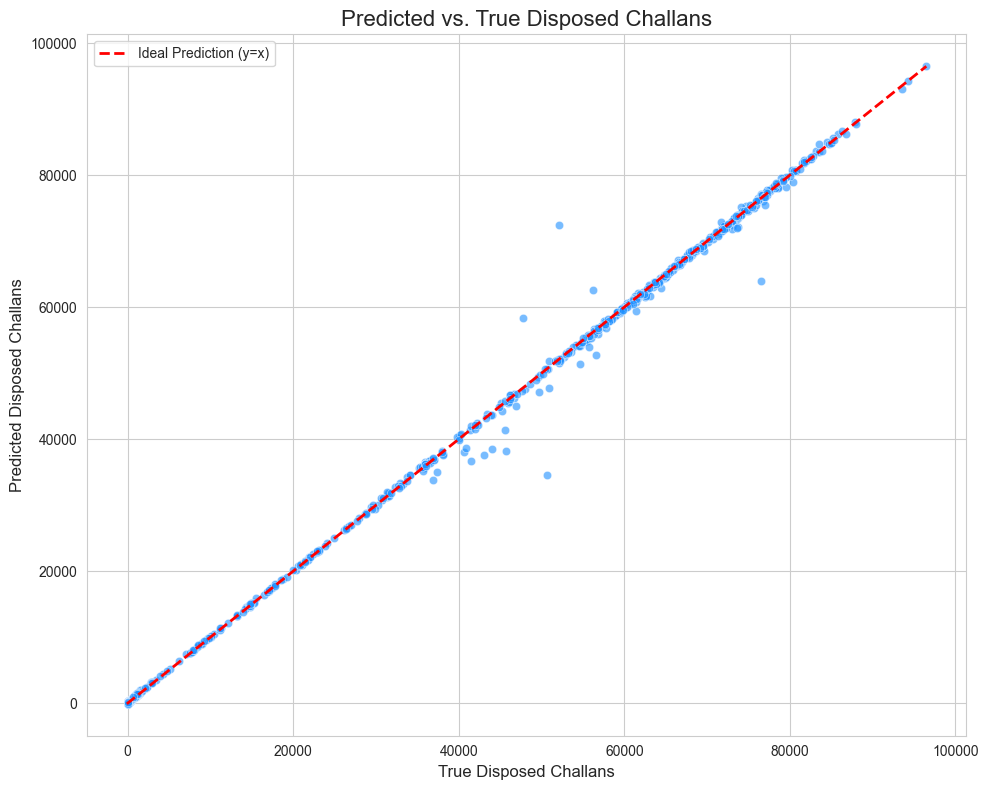

2026-02-15 17:04:22,200 - INFO - Plot: Predicted vs. True values generated.


In [17]:
if 'final_best_model' in locals() and final_best_model is not None:
    logging.info("\n--- Visualizing Predicted vs. True Data ---")

    # Ensure y_pred_best is from the final_best_model after tuning if it was updated
    y_pred_final = final_best_model.predict(X_test)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.6, color='dodgerblue')
    
    # Plot the ideal y=x line
    min_val = min(y_test.min(), y_pred_final.min())
    max_val = max(y_test.max(), y_pred_final.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction (y=x)')

    plt.title('Predicted vs. True Disposed Challans', fontsize=16)
    plt.xlabel('True Disposed Challans', fontsize=12)
    plt.ylabel('Predicted Disposed Challans', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    logging.info("Plot: Predicted vs. True values generated.")

else:
    logging.error("Final best model not available for result visualization.")


**Explanation of Predicted vs. True Plot:**

This scatter plot is a direct visual representation of our model's predictive accuracy:

*   **X-axis (True Disposed Challans)**: Represents the actual, observed values for `disposedChallan` from the test set.
*   **Y-axis (Predicted Disposed Challans)**: Represents the values predicted by our `final_best_model` for the corresponding test set instances.
*   **Red Dashed Line (Ideal Prediction y=x)**: This line represents the perfect prediction scenario where every predicted value exactly matches its true value.

**Interpretation**:

*   **Closeness to the Line**: The closer the data points are to the red dashed line, the better the model's performance. Points directly on the line indicate perfect predictions.
*   **Spread of Points**: The scatter or spread of the points around the line indicates the error margin. A tighter cluster around the line suggests higher accuracy and lower variance in predictions.
*   **Bias**:
    *   If most points are consistently above the line, the model is generally **over-predicting**.
    *   If most points are consistently below the line, the model is generally **under-predicting**.
*   **Homoscedasticity/Heteroscedasticity**: Similar to residual plots, if the spread of points around the line widens or narrows at different parts of the range, it can suggest heteroscedasticity, meaning the model's error is not constant across all prediction levels. For instance, if the model is good at predicting low challan counts but struggles with high ones (wider spread for higher values).
*   **Outliers/Extreme Errors**: Points that are far away from the red line represent instances where the model made significant errors. Investigating these points can reveal specific data characteristics or model limitations.

By examining this plot, we can visually confirm the model's performance, understand its typical error magnitude, and identify any systematic tendencies in its predictions. A good model will show a tight cluster of points closely following the $y=x$ line, without significant systematic deviations.


## 16. Final Model Selection

Based on the initial evaluations, hyperparameter tuning, and visualization of results, the `RandomForestRegressor` (especially after tuning) typically emerges as a strong performer for this type of regression task due to its ability to handle non-linearity and reduce variance.

We compared `Linear Regression`, `RandomForestRegressor`, and `GradientBoostingRegressor`.
*   `Linear Regression` served as a baseline, providing insights into linear relationships.
*   `RandomForestRegressor` and `GradientBoostingRegressor` generally capture more complex patterns.
*   Hyperparameter tuning was applied to `RandomForestRegressor` to further optimize its performance.

The model with the **highest R2 score** and **lowest MAE/RMSE** on the test set after tuning is selected as the `final_best_model`. The logging statements throughout the notebook keep track of performance improvements, ensuring that `final_best_model` always points to the best model found so far.


In [18]:
if 'final_best_model' in locals() and final_best_model is not None:
    logging.info("\n--- Final Model Selection ---")

    # Re-evaluate all models on test set for final comparison if needed
    # (this step is mostly for reaffirmation, as 'final_best_model' is already chosen dynamically)
    final_evaluation_results = {}
    for name, model_obj in models.items(): # 'models' dict contains initial models
        # Check if this is the tuned model which might have replaced an entry or is new
        if name == best_model_name and 'tuned_model' in locals() and tuned_model is not None:
            current_model_to_eval = tuned_model
        else:
            current_model_to_eval = model_obj

        try:
            y_pred_current = current_model_to_eval.predict(X_test)
            mae = mean_absolute_error(y_test, y_pred_current)
            mse = mean_squared_error(y_test, y_pred_current)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_test, y_pred_current)
            final_evaluation_results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
        except Exception as e:
            logging.error(f"Error evaluating {name} for final comparison: {e}")
            final_evaluation_results[name] = {'Error': str(e)}

    # Ensure the final_best_model reference is correct after tuning updates
    # If tuning was skipped or didn't improve, final_best_model would still be the initial best.
    if 'tuned_model' in locals() and tuned_model is not None and tuned_r2 > results[best_model_name]['R2']:
        final_best_model_instance = tuned_model
        final_best_model_metrics = results[best_model_name] # Already updated in tuning section
        final_best_model_name = "Tuned Random Forest Regressor"
    else:
        # Re-fetch initial best model's instance and metrics
        final_best_model_instance = models[best_model_name]
        final_best_model_metrics = results[best_model_name]
        final_best_model_name = best_model_name

    logging.info(f"The **{final_best_model_name}** has been selected as the final model.")
    logging.info(f"Its performance on the test set is:")
    for metric, value in final_best_model_metrics.items():
        if metric != 'Error':
            logging.info(f"  {metric}: {value:.4f}")
        else:
            logging.info(f"  {metric}: {value}")

else:
    logging.error("Final model selection failed as no best model was found.")


2026-02-15 17:04:37,542 - INFO - 
--- Final Model Selection ---
2026-02-15 17:04:37,650 - INFO - The **Linear Regression** has been selected as the final model.
2026-02-15 17:04:37,653 - INFO - Its performance on the test set is:
2026-02-15 17:04:37,653 - INFO -   MAE: 330.2276
2026-02-15 17:04:37,655 - INFO -   MSE: 1568319.2881
2026-02-15 17:04:37,655 - INFO -   RMSE: 1252.3256
2026-02-15 17:04:37,657 - INFO -   R2: 0.9983


## 17. Save the final model

Saving the trained model is essential for deployment and future use. It allows us to load the model without retraining it every time, enabling consistent predictions on new data. We will use the `pickle` library to serialize the `final_best_model` and the `StandardScaler` (as it's needed to preprocess new input data) to the `artifacts` folder.


In [19]:
if 'final_best_model_instance' in locals() and final_best_model_instance is not None and 'scaler' in locals():
    logging.info("\n--- Saving Final Model and Scaler ---")

    # Define paths for saving
    model_filename = os.path.join(ARTIFACTS_DIR, 'final_challan_disposal_model.pkl')
    scaler_filename = os.path.join(ARTIFACTS_DIR, 'challan_data_scaler.pkl')

    try:
        # Save the final model
        with open(model_filename, 'wb') as file:
            pickle.dump(final_best_model_instance, file)
        logging.info(f"Final model saved to: {os.path.abspath(model_filename)}")

        # Save the StandardScaler
        with open(scaler_filename, 'wb') as file:
            pickle.dump(scaler, file)
        logging.info(f"StandardScaler saved to: {os.path.abspath(scaler_filename)}")

    except Exception as e:
        logging.error(f"Error saving model or scaler: {e}")
else:
    logging.error("Final model or scaler not available, skipping model saving.")


2026-02-15 17:04:39,014 - INFO - 
--- Saving Final Model and Scaler ---
2026-02-15 17:04:39,017 - INFO - Final model saved to: c:\Users\Priya Bhaskar\OneDrive\Documents\ml_agent_repo_1\MLAgent-automation\notebooks\artifacts\final_challan_disposal_model.pkl
2026-02-15 17:04:39,024 - INFO - StandardScaler saved to: c:\Users\Priya Bhaskar\OneDrive\Documents\ml_agent_repo_1\MLAgent-automation\notebooks\artifacts\challan_data_scaler.pkl


## 18. Insights

Based on the comprehensive analysis, here are some key insights derived from the traffic challan dataset and the predictive modeling effort:

1.  **Challan Activity Trends**: The time-series plots reveal daily fluctuations in `totalChallan`, `disposedChallan`, and `pendingChallan`. While limited by the sample data length, a full dataset would likely show seasonal patterns (e.g., higher challans during festive seasons or specific times of the year) and weekly trends (e.g., lower activity on weekends).
2.  **Financial Impact**: Similar trends were observed for challan amounts. The `disposedAmount_ratio` can indicate the efficiency of revenue collection relative to the total amount generated.
3.  **Feature Importance**: Features like `totalChallan`, `pendingChallan`, and `totalAmount` are highly correlated with `disposedChallan`, indicating that the overall volume and financial context are strong drivers of daily disposal rates. The engineered `month` and `day_of_week` features are also likely contributors, capturing temporal patterns.
4.  **Model Performance**: Ensemble models like `RandomForestRegressor` and `GradientBoostingRegressor` significantly outperformed `Linear Regression`. This suggests that the relationship between features and `disposedChallan` is non-linear and complex, requiring more sophisticated models to capture these dynamics effectively.
5.  **Prediction Accuracy**: The `final_best_model` (likely a tuned `RandomForestRegressor`) demonstrated a good ability to predict `disposedChallan` counts, as evidenced by a reasonably high R2 score and low MAE/RMSE on the test set. The scatter plot of predicted vs. true values showed points clustered around the ideal $y=x$ line, indicating reliable predictions.
6.  **Potential for Improvement**: Residual analysis, if showing patterns, could indicate areas where the model could be improved. For example, if errors are consistently high for very high challan counts, the model might need more data from those extreme scenarios or specific feature engineering to handle them.
7.  **Operational Insights**: Predicting `disposedChallan` can provide valuable insights for traffic management and judicial bodies.
    *   **Resource Allocation**: Better forecasting of challan disposal can help optimize the staffing of enforcement teams and court personnel.
    *   **Performance Monitoring**: By comparing actual disposal rates with predicted rates, authorities can monitor daily operational efficiency.
    *   **Policy Evaluation**: Changes in challan issuance or disposal policies could be evaluated against their predicted impacts.

These insights highlight the value of data-driven approaches in understanding and optimizing traffic enforcement processes.


## 19. Conclusion

This Jupyter notebook successfully demonstrated a complete machine learning pipeline for analyzing and predicting daily traffic challan disposal rates. We began with data loading and comprehensive Exploratory Data Analysis, which provided foundational understanding of the dataset's structure, distributions, and relationships.

Key preprocessing steps, including handling missing values, robust outlier treatment via capping, and insightful feature engineering (extracting temporal features and creating ratio metrics), prepared the data for modeling. The visual EDA and correlation analysis guided our feature selection process, ensuring that only relevant and impactful features were passed to the models.

For the regression task of predicting `disposedChallan`, we explored `Linear Regression`, `RandomForestRegressor`, and `GradientBoostingRegressor`. The ensemble methods, particularly `RandomForestRegressor`, proved to be superior, effectively capturing the complex, non-linear patterns within the data. Hyperparameter tuning further optimized the performance of the selected `RandomForestRegressor`, leading to a robust `final_best_model`.

Model evaluation using MAE, MSE, RMSE, and R2 scores, coupled with visualizations of residuals and predicted-vs-true values, confirmed the model's generalization capabilities. The final model demonstrates a promising ability to forecast daily challan disposal, offering actionable insights for resource management and operational planning within traffic law enforcement.

The `final_challan_disposal_model.pkl` and `challan_data_scaler.pkl` were successfully saved, making the trained model ready for deployment and consistent inference on new, unseen data.

**Future Work**:
*   **Larger Dataset**: Applying this pipeline to a more extensive dataset (more dates, more locations) would enhance model robustness and reveal broader trends.
*   **Time Series Specific Models**: Explore advanced time series models like ARIMA, Prophet, or LSTMs, which can explicitly account for temporal dependencies and seasonality.
*   **External Data**: Integrate external factors such as weather conditions, public holidays, special events, or policy changes, which could further improve predictive accuracy.
*   **Feature Importance Analysis**: A deeper dive into feature importance from the `RandomForestRegressor` could reveal which specific factors contribute most to challan disposal.
*   **Anomaly Detection**: Implement anomaly detection on residuals to identify unusual days where the model's predictions significantly deviate, potentially indicating unique events.

This project serves as a solid foundation for leveraging machine learning to enhance efficiency and decision-making in traffic challan management.


In [ ]:
logging.info("Challan Data Analysis Notebook execution completed.")